# 0.0 IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import inflection
import math
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image
from scipy import stats as ss
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder


### 0.1 Helper functions

In [3]:
def cramer_v(x,y): #x e y são as variaveis categorias das quais eu quero calculas a correlação
    cm = pd.crosstab(x, y).to_numpy() #faz combinações com os parâmetros passados, ou seja, state_holiday == christmas & store_type == a, existem 4 linhas. Essa regra se repete para todos os outros
    n = cm.sum()
    r, k = cm.shape

    chi2 = ss.chi2_contingency( cm )[0]
    chi2corr = max ( 0, chi2 - (k-1)* (r-1) / (n-1))

    kcorr = k - (k-1)**2 / (n-1)
    rcorr = r - (r-1)**2 / (n-1)
    return np.sqrt( ( chi2corr/n) / (min (kcorr-1, rcorr-1) ) )

### 0.2 Loading data

In [4]:
df_sales_raw = pd.read_csv('../Dados/train.csv', low_memory=False)
df_store_raw = pd.read_csv('../Dados/store.csv', low_memory=False)

#merge(uniao)

df_raw = pd.merge(df_sales_raw, df_store_raw, how='left', on='Store') #o store é a coluna igual nos 2 df para fazer a união

# 1.0 PASSO 1 DESCRIÇÃO DOS DADOS

In [5]:
df1 = df_raw.copy()

In [6]:
df_raw.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='str')

### 1.1 Rename Columns

In [7]:
cols_old = ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
            'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
            'CompetitionDistance', 'CompetitionOpenSinceMonth',
            'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
            'Promo2SinceYear', 'PromoInterval']


snackcase = lambda x: inflection.underscore(x)

cols_new = list(map(snackcase, cols_old))

df1.columns = cols_new

### 1.2 Data Dimensions

In [8]:
print('n de linhas: {}'.format(df1.shape[0]))
print('n de colunas: {}'.format(df1.shape[1]))

n de linhas: 1017209
n de colunas: 18


### 1.3 Data Types

In [9]:
df1['date'] = pd.to_datetime(df1['date'])
df1.dtypes

store                                    int64
day_of_week                              int64
date                            datetime64[us]
sales                                    int64
customers                                int64
open                                     int64
promo                                    int64
state_holiday                              str
school_holiday                           int64
store_type                                 str
assortment                                 str
competition_distance                   float64
competition_open_since_month           float64
competition_open_since_year            float64
promo2                                   int64
promo2_since_week                      float64
promo2_since_year                      float64
promo_interval                             str
dtype: object

### 1.4 Check NA

In [10]:
df1.isna().sum()

store                                0
day_of_week                          0
date                                 0
sales                                0
customers                            0
open                                 0
promo                                0
state_holiday                        0
school_holiday                       0
store_type                           0
assortment                           0
competition_distance              2642
competition_open_since_month    323348
competition_open_since_year     323348
promo2                               0
promo2_since_week               508031
promo2_since_year               508031
promo_interval                  508031
dtype: int64

### 1.5 Fillout NA

In [11]:
# competition_open_since_month	
df1['competition_open_since_month'] = df1['competition_open_since_month'].fillna(df1['date'].dt.month)

# competition_open_since_year 
df1['competition_open_since_year'] = df1['competition_open_since_year'].fillna(df1['date'].dt.year)
	
# promo2_since_week	   
df1['promo2_since_week'] = df1['promo2_since_week'].fillna(df1['date'].dt.month)
 
# promo2_since_year   	
df1['promo2_since_year'] = df1['promo2_since_year'].fillna(df1['date'].dt.year)

# promo_interval	
month_map = {1: 'Jan',
 2: 'Fev',
 3: 'Mar',
 4: 'Apr',
 5: 'May',
 6: 'Jun',
 7: 'Jul',
 8: 'Aug',
 9: 'Set',
 10: 'Oct',
 11: 'Nov',
 12: 'Dec'} 

df1['promo_interval'] = df1['promo_interval'].fillna('0',inplace=True) #inplace aplica o valor direto na coluna

df1['month_map'] = df1['date'].dt.month.map(month_map)

df1['is_promo'] = df1[['promo_interval','month_map']].apply( lambda x: 0 if x['promo_interval'] == 0 else 1 if x['month_map'] in x['promo_interval'].split(',') else 0, axis=1)


                

/tmp/ipykernel_1846/3584883733.py:27: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df1['promo_interval'] = df1['promo_interval'].fillna('0',inplace=True) #inplace aplica o valor direto na coluna


### 1.6 Change Types

In [12]:
df1['competition_open_since_month'] = df1['competition_open_since_month'].astype(int)
df1['competition_open_since_year'] = df1['competition_open_since_year'].astype(int)
df1['promo2_since_week'] = df1['promo2_since_week'].astype(int)
df1['promo2_since_year'] = df1['promo2_since_year'].astype(int)

### 1.7 Description estatistic

In [13]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64[ns]'])

### 1.7.1 Numerical attributes

In [14]:
#Medidas de têndencia central - mean, median
ct1 = pd.DataFrame( num_attributes.apply(np.mean) ).T
ct2 = pd.DataFrame( num_attributes.apply(np.median) ).T


#Medidas de disperção - min, max, range, kurtose, skew, std
d1 = pd.DataFrame(num_attributes.apply(np.std) ).T
d2 = pd.DataFrame(num_attributes.apply(np.min) ).T
d3 = pd.DataFrame(num_attributes.apply(np.max) ).T
d4 = pd.DataFrame((num_attributes.max() - num_attributes.min())).T
d5 = pd.DataFrame(num_attributes.skew() ).T
d6 = pd.DataFrame(num_attributes.kurtosis() ).T

#Concat
m = pd.concat( [d2, d3, d4, ct1, ct2, d1, d5, d6] ).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']


#Maneira mais direta de fazer 

# m = pd.DataFrame({
#     'min': num_attributes.min(),
#     'max': num_attributes.max(),
#     'range': num_attributes.max() - num_attributes.min(),
#     'mean': num_attributes.mean(),
#     'median': num_attributes.median(),
#     'std': num_attributes.std(),
#     'skew': num_attributes.skew(),
#     'kurtosis': num_attributes.kurtosis()
# }).reset_index()

# m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']

/tmp/ipykernel_1846/710812770.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['sales'])


<Axes: xlabel='sales', ylabel='Density'>

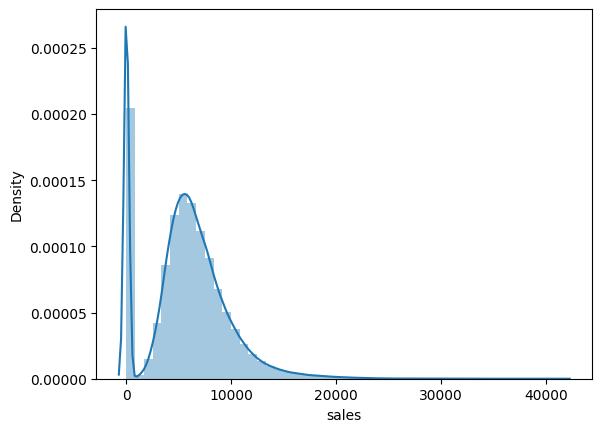

In [15]:
sns.distplot(df1['sales'])

### 1.7.2 Categorical attributes

In [16]:
cat_attributes.nunique()

state_holiday      4
store_type         4
assortment         3
promo_interval     4
month_map         12
dtype: int64

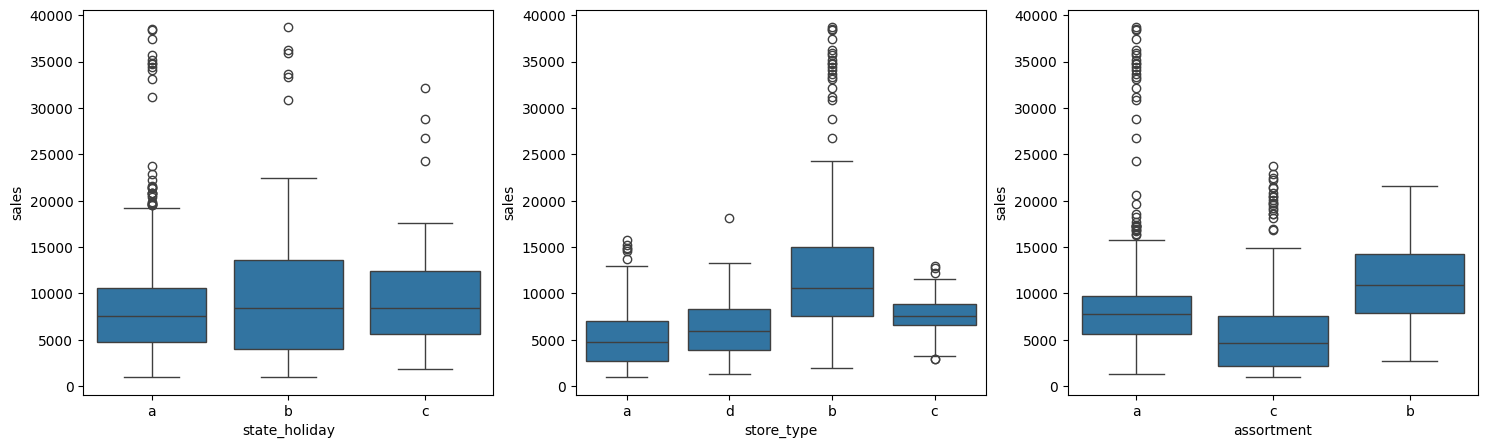

In [17]:
aux1 = df1[(df1['state_holiday'] != '0') & (df1['sales'] >0)]

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
sns.boxplot(x='state_holiday', y='sales', data=aux1)

plt.subplot(1,3,2)
sns.boxplot(x='store_type', y='sales', data=aux1)

plt.subplot(1,3,3)
sns.boxplot(x='assortment', y='sales', data=aux1)

plt.show()

# PASSO 2 2.0 FEATURE ENGINEERING

In [18]:
df2 = df1.copy()

### 2.1 Mapa de hipoteses

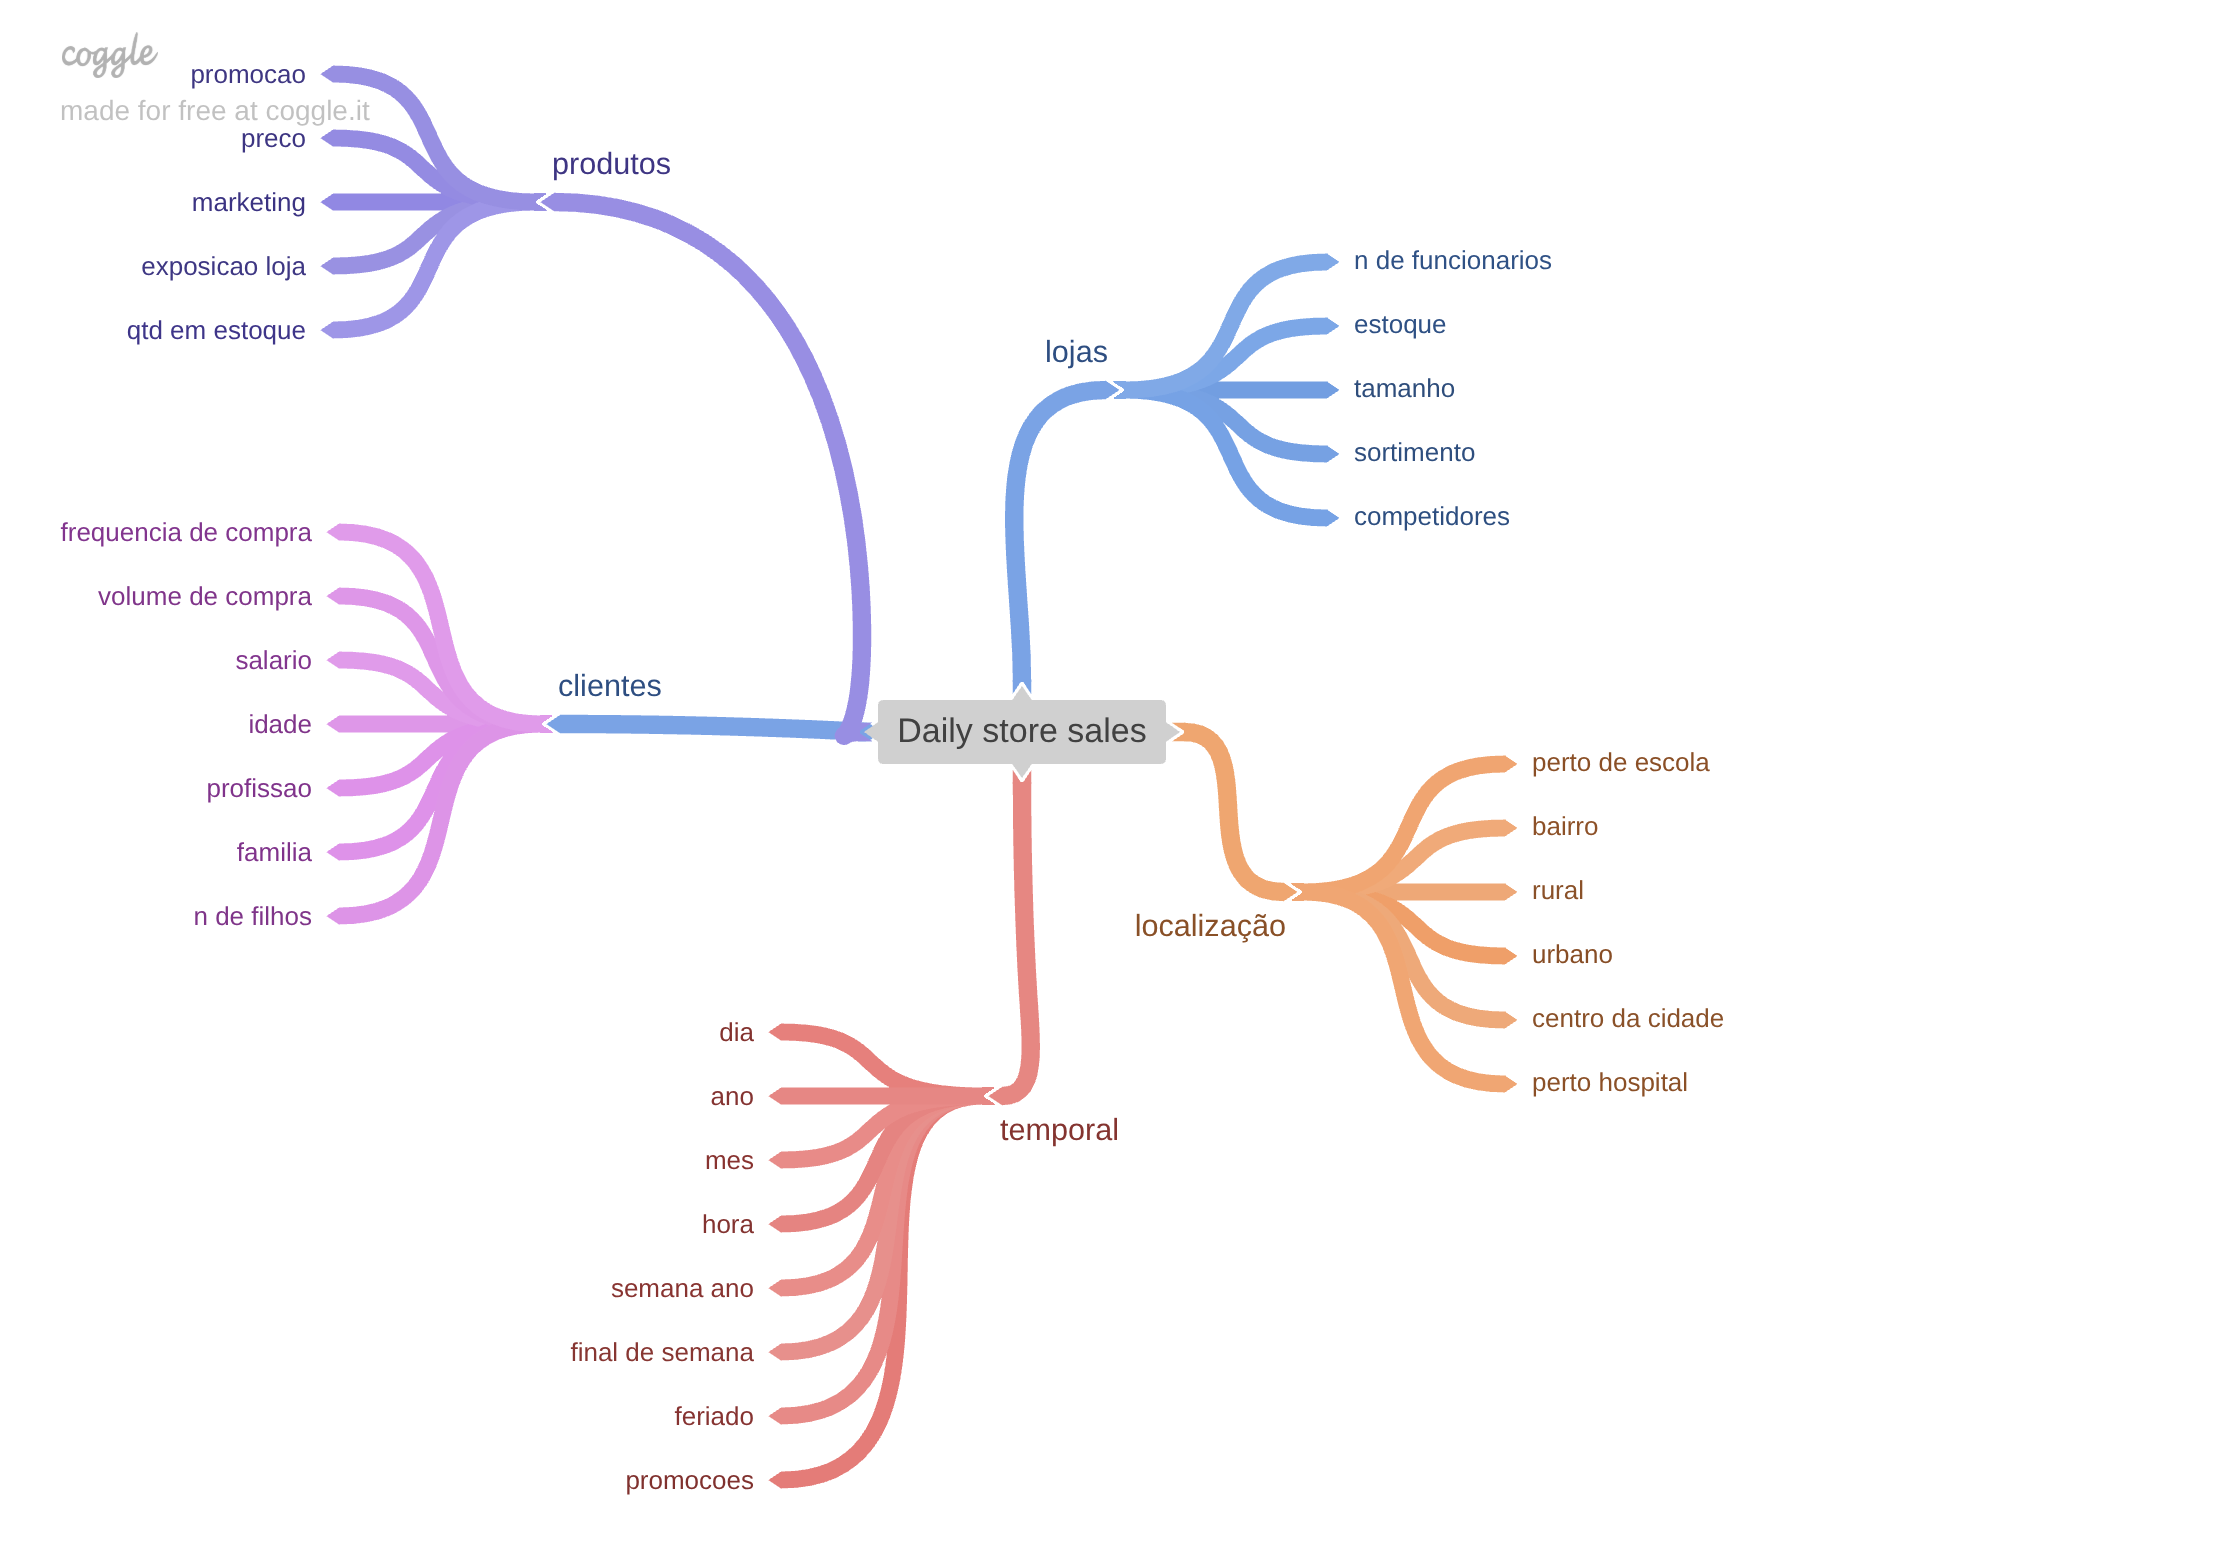

In [19]:
Image('../Img/BI.png')

### 2.1.1 Hipoteses das lojas

**1.** Lojas com número maior de funcionários deveriam vender mais.

**2.** Lojas com maior capacidade de estoque deveriam vender mais.

**3.** Lojas com maior porte deveriam vender mais.

**4.** Lojas com maior sortimentos deveriam vender mais.

**5.** Lojas com competidores mais próximos deveriam vender menos.

**6.** Lojas com competidores a mais longa distância deveriam vender mais.

### 2.1.1 Hipoteses dos produtos

**1.** Lojas que investem mais em Marketing deveriam vender mais.

**2.** Lojas com maior exposição de produto deveriam vender mais.

**3.** Lojas com produtos com preço menor deveriam vender mais.

**5.** Lojas com promoções mais agressivas ( descontos maiores ), deveriam vender mais.

**6.** Lojas com promoções ativas por mais tempo deveriam vender mais.

**7.** Lojas com mais dias de promoção deveriam vender mais.

**8.** Lojas com mais promoções consecutivas deveriam vender mais.

### 2.1.1 Hipoteses do tempo

**1.** Lojas abertas durante o feriado de Natal deveriam vender mais.

**2.** Lojas deveriam vender mais ao longo dos anos.

**3.** Lojas deveriam vender mais no segundo semestre do ano.

**4.** Lojas deveriam vender mais depois do dia 10 de cada mês.

**5.** Lojas deveriam vender menos aos finais de semana.

**6.** Lojas deveriam vender menos durante os feriados escolares.

## 2.2 Lista final de hipoteses

**1.** Lojas com maior sortimentos deveriam vender mais.

**2.** Lojas com competidores mais próximos deveriam vender menos.

**3.** Lojas com competidores à mais tempo deveriam vendem mais.

**4.** Lojas com promoções ativas por mais tempo deveriam vender mais.

**5.** Lojas com mais dias de promoção deveriam vender mais.

**6.** Lojas com mais promoções consecutivas deveriam vender mais.

**7.** Lojas abertas durante o feriado de Natal deveriam vender mais.

**8.** Lojas deveriam vender mais ao longo dos anos.

**9.** Lojas deveriam vender mais no segundo semestre do ano.

**10.** Lojas deveriam vender mais depois do dia 10 de cada mês.

**11.** Lojas deveriam vender menos aos finais de semana.

**12.** Lojas deveriam vender menos durante os feriados escolares.

## 2.3 FEATURE ENGINEERING

In [20]:
#year
df2['year'] = pd.to_datetime(df2['date']).dt.year
#month
df2['month'] = pd.to_datetime(df2['date']).dt.month
#day
df2['day'] = pd.to_datetime(df2['date']).dt.day
#week of year
df2['week_of_year'] = df2['date'].dt.isocalendar().week
#year week
df2['year_week'] = df2['date'].dt.strftime('%Y-%W')

#competition since
df2['competition_since'] = pd.to_datetime(dict(year=df2['competition_open_since_year'], month=df2['competition_open_since_month'],day=1))
df2['competition_time_month'] = (df2['date'] - df2['competition_since']).dt.days // 30

#promo since
df2['promo_since'] = pd.to_datetime(df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str) + '-1', format='%Y-%W-%w') - pd.to_timedelta(7, unit='d')
df2['promo_time_week'] = (df2['date'] - df2['promo_since']).dt.days // 7

#assortment
df2['assortment'] = df2['assortment'].replace({
    'a' : 'basic',
    'b' : 'extra',
    'c' : 'extended'
})


#state holiday
df2['state_holiday'] = df2['state_holiday'].replace({
    'a' : 'public_holiday',
    'b' : 'easter_holiday',
    'c' : 'christmas',
    '0' : 'regular_day'
})


/tmp/ipykernel_1846/4262844899.py:17: Pandas4Warning: 'd' is deprecated and will be removed in a future version. Please use 'D' instead of 'd'.
  df2['promo_since'] = pd.to_datetime(df2['promo2_since_year'].astype(str) + '-' + df2['promo2_since_week'].astype(str) + '-1', format='%Y-%W-%w') - pd.to_timedelta(7, unit='d')


In [21]:
cat_attributes = df2[['state_holiday', 'store_type', 'assortment', 'year_week']]

# PASSO 3 3.0 FILTRAGEM DE VARIAVEIS

In [22]:
df3 = df2.copy()

In [23]:
df3

,store,day_of_week,date,sales,customers,open,promo,state_holiday,school_holiday,store_type,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,555,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-02-09,24
1,2,5,2015-07-31,6064,625,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,821,1,1,regular_day,1,a,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1498,1,1,regular_day,1,c,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-02-09,24
4,5,5,2015-07-31,4822,559,1,1,regular_day,1,a,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-02-09,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,public_holiday,1,a,...,1,2013,1,1,1,2013-00,2014-06-01,-18,2013-07-29,-30
1017205,1112,2,2013-01-01,0,0,0,0,public_holiday,1,c,...,0,2013,1,1,1,2013-00,2006-04-01,82,2012-12-31,0
1017206,1113,2,2013-01-01,0,0,0,0,public_holiday,1,a,...,0,2013,1,1,1,2013-00,2013-01-01,0,2012-12-31,0
1017207,1114,2,2013-01-01,0,0,0,0,public_holiday,1,a,...,0,2013,1,1,1,2013-00,2013-01-01,0,2012-12-31,0


## Filtragem das linhas

In [24]:
df3 = df3[(df3['open'] != 0) & (df3['sales'] > 0)]

## Selecao das colunas

In [25]:
cols_drop = ['customers', 'open', 'promo_interval', 'month_map']
df3 = df3.drop (cols_drop, axis=1)

# PASSO 4 4.0 ANÁLISE EXPLORATÓRIA DE DADOS

In [26]:
df4 = df3.copy()

## 4.1 Análise Univariada

### 4.1.1 Response variable

<Axes: xlabel='sales', ylabel='Density'>

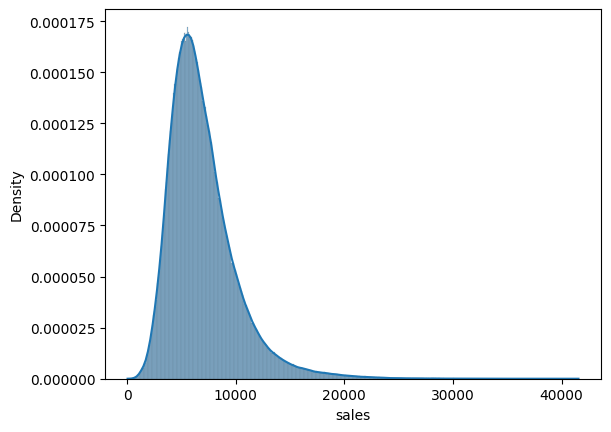

In [27]:
sns.histplot(df4['sales'], kde=True, stat='density')

### 4.1.2 Numerical variable

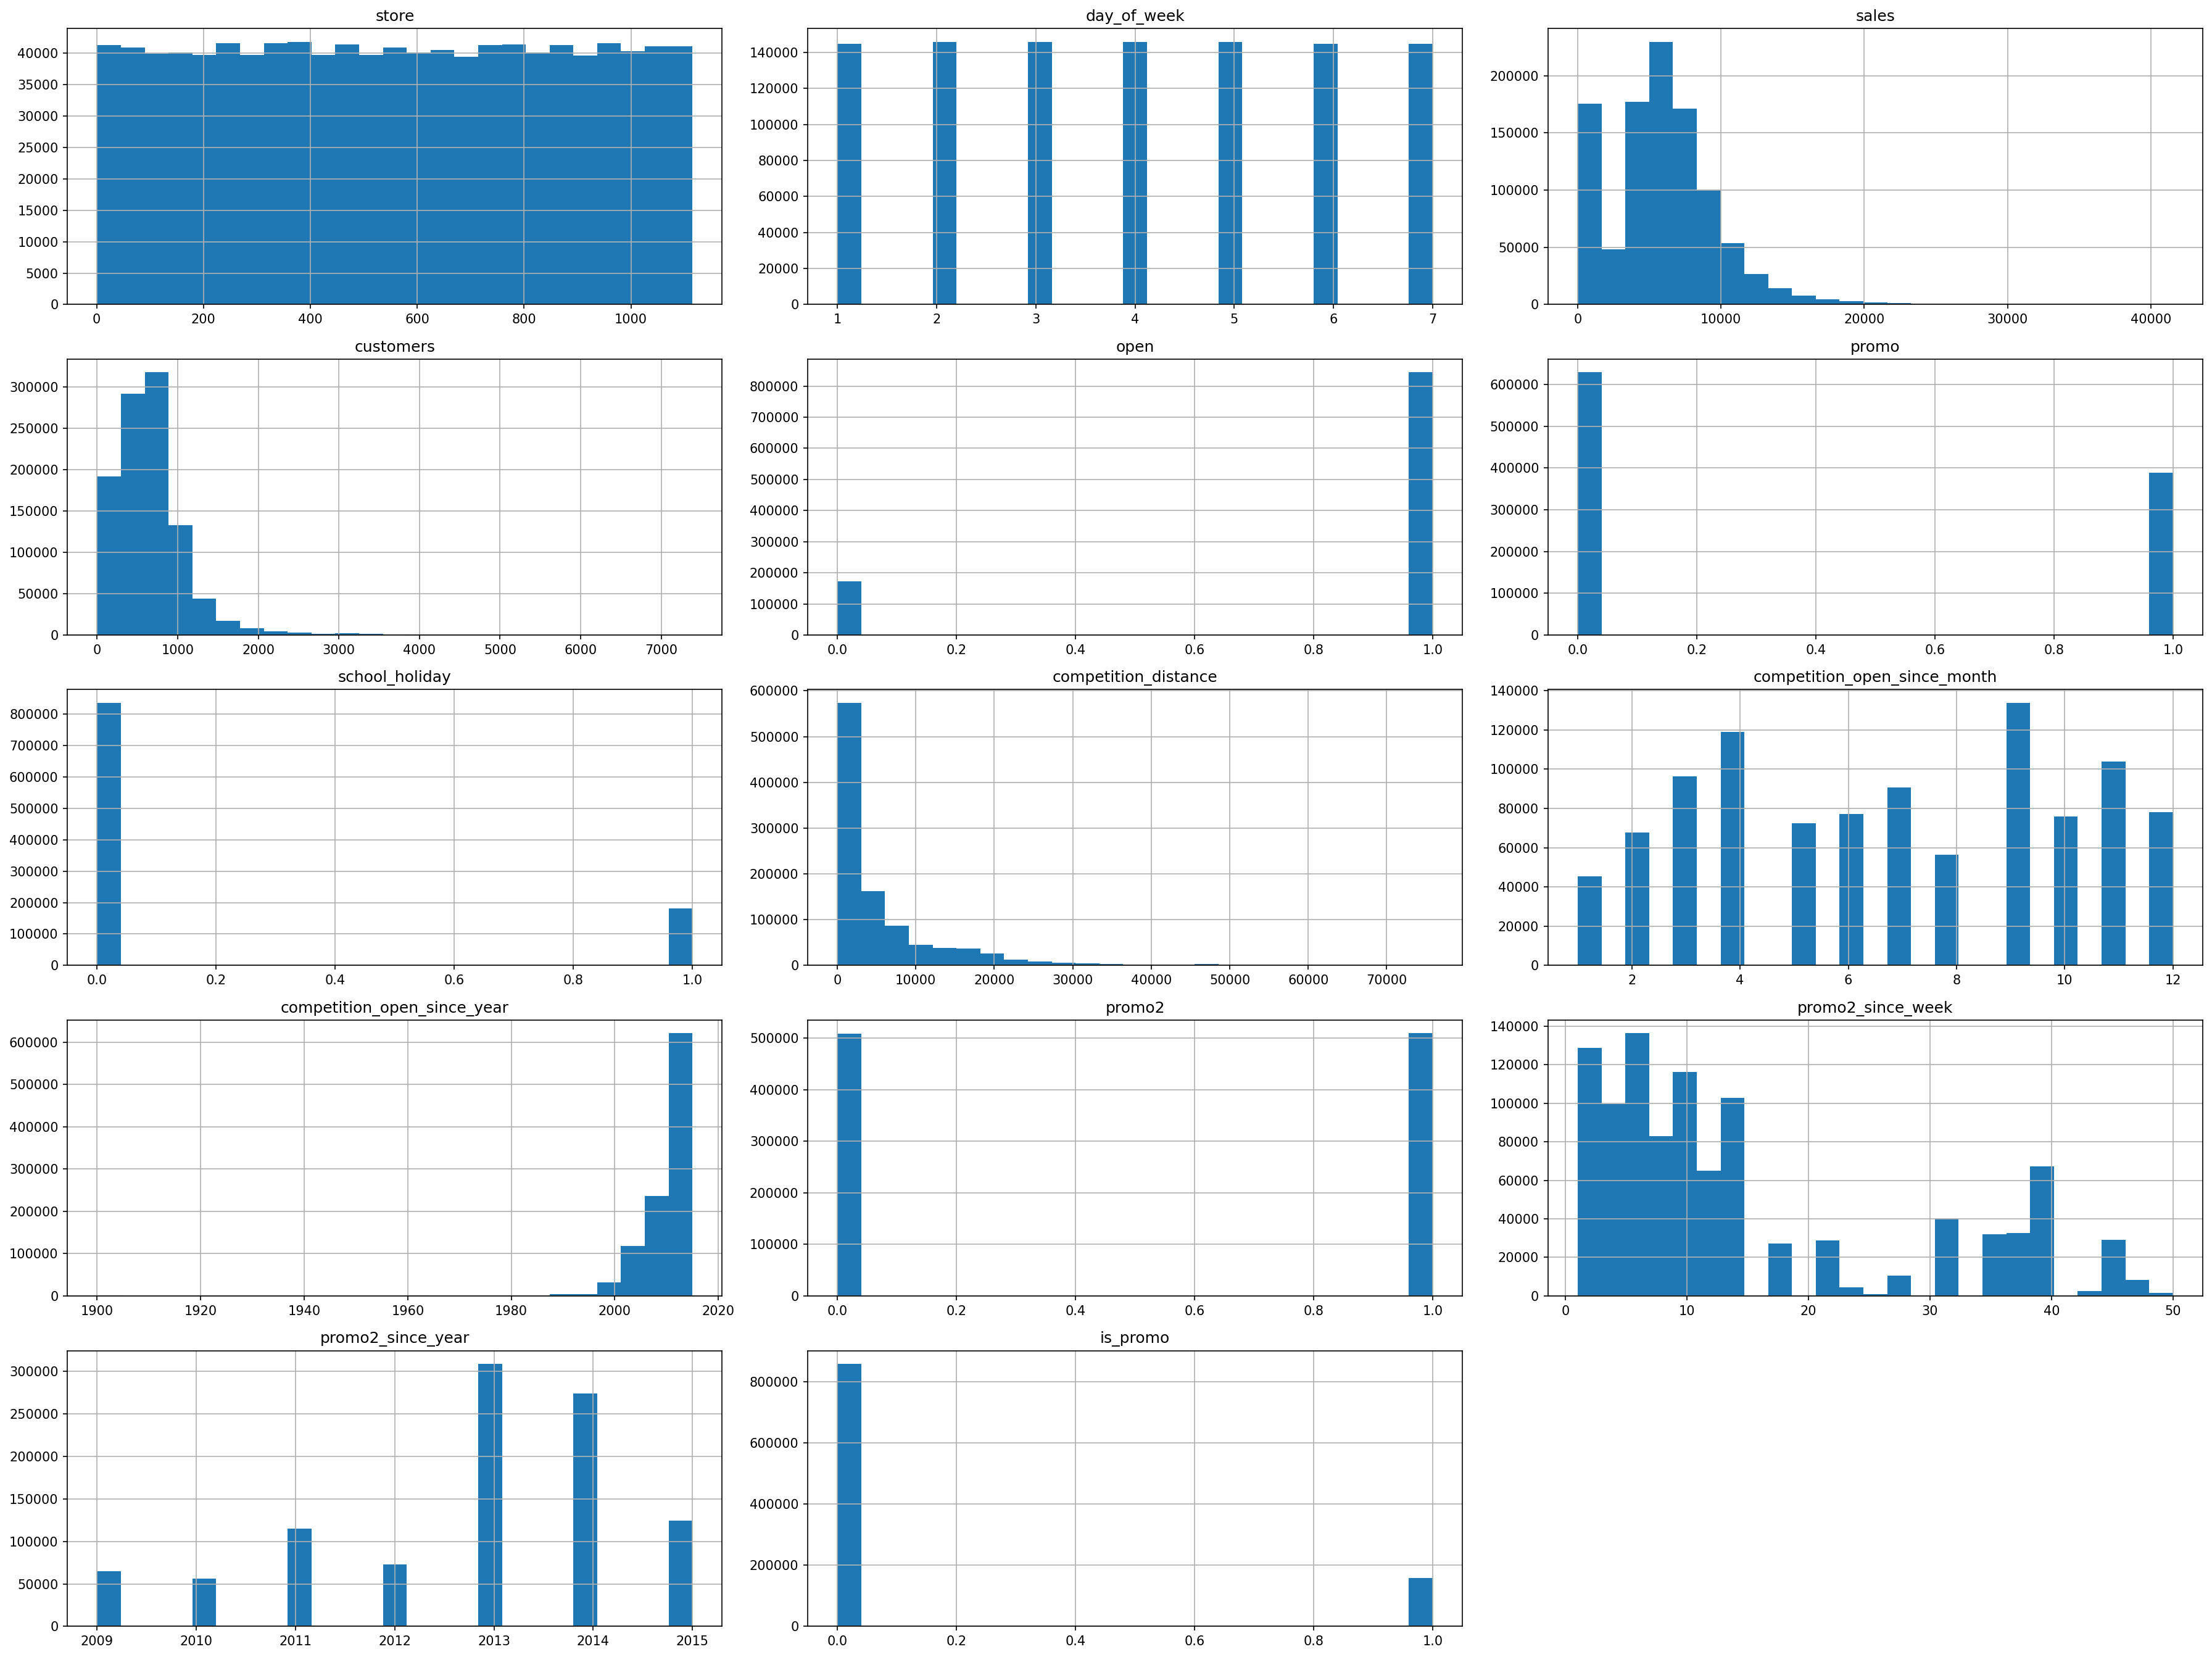

In [28]:
plt.rcParams['figure.dpi'] = 150

num_attributes.hist(bins=25, figsize=(24, 18), layout=(5, 3))
plt.tight_layout()
plt.show()

### 4.1.3 Categorical variable

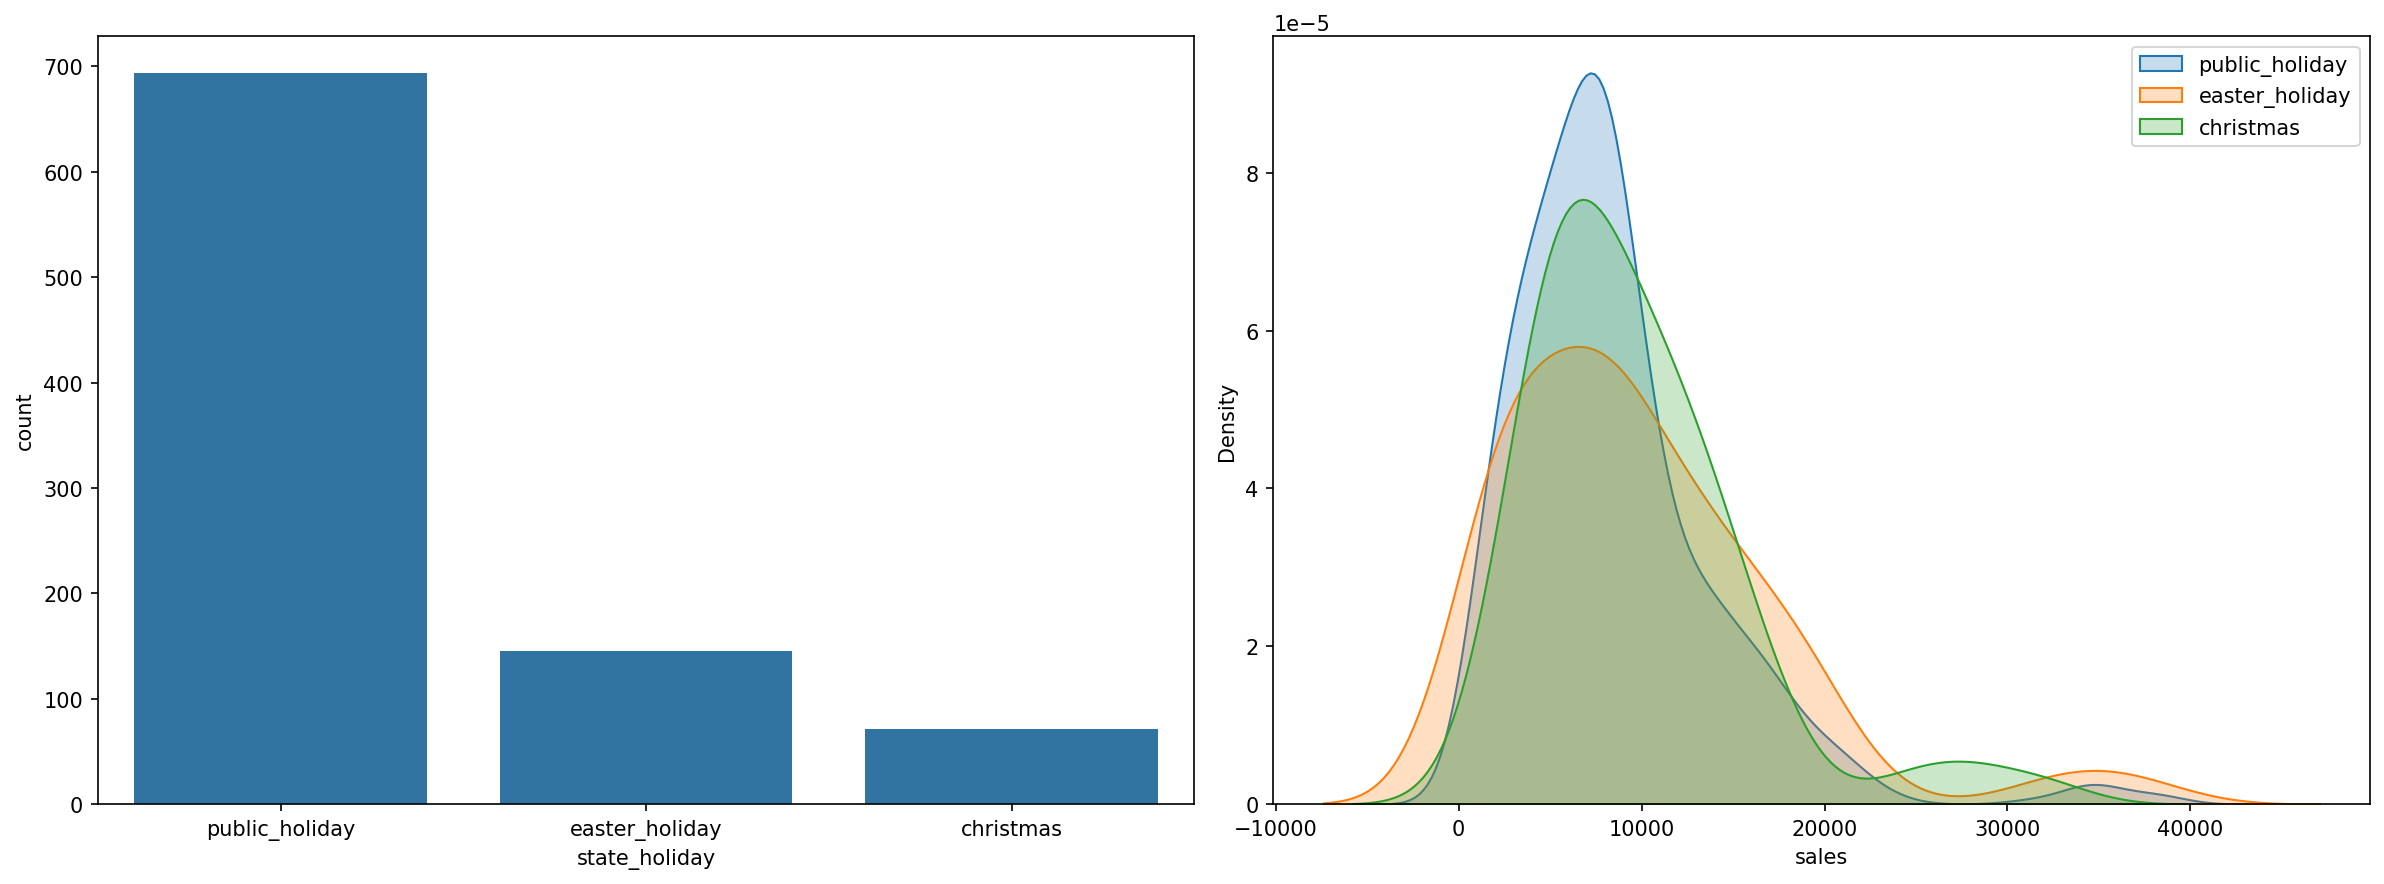

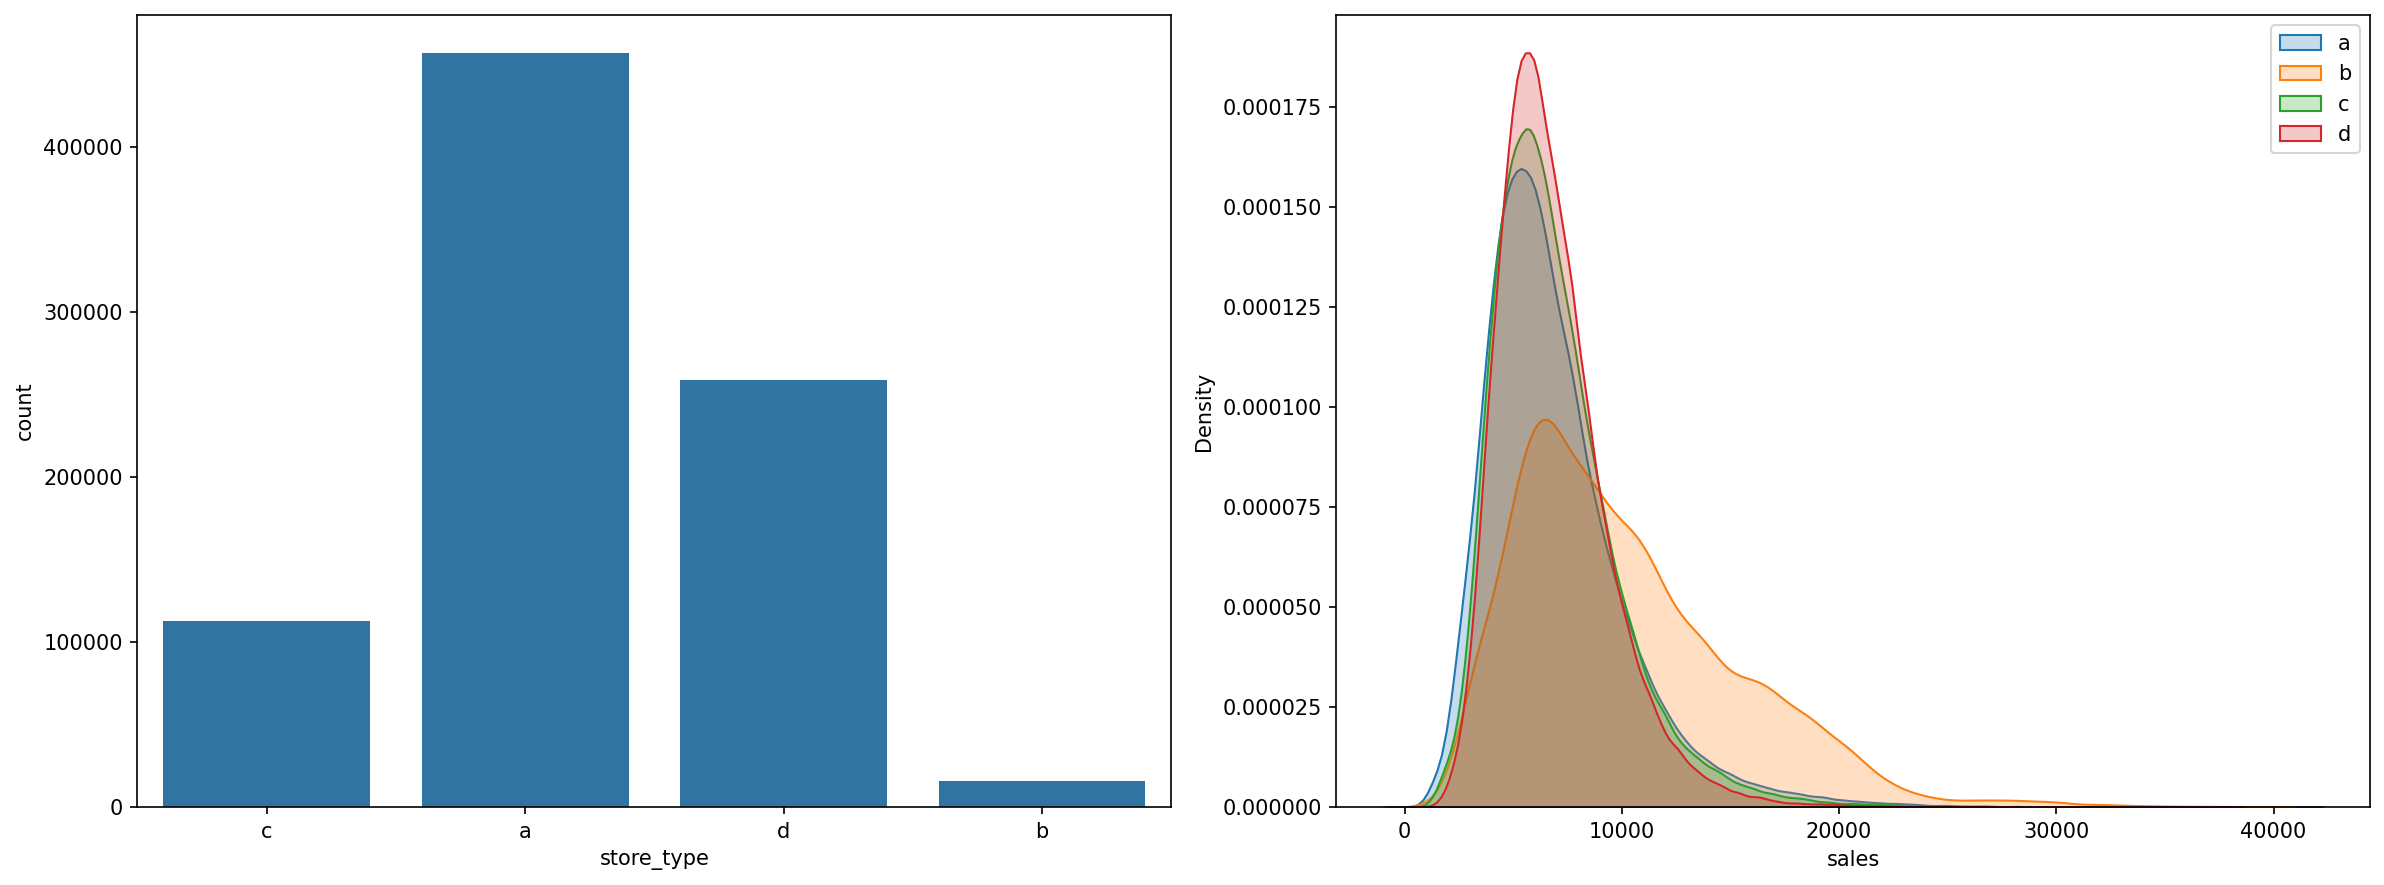

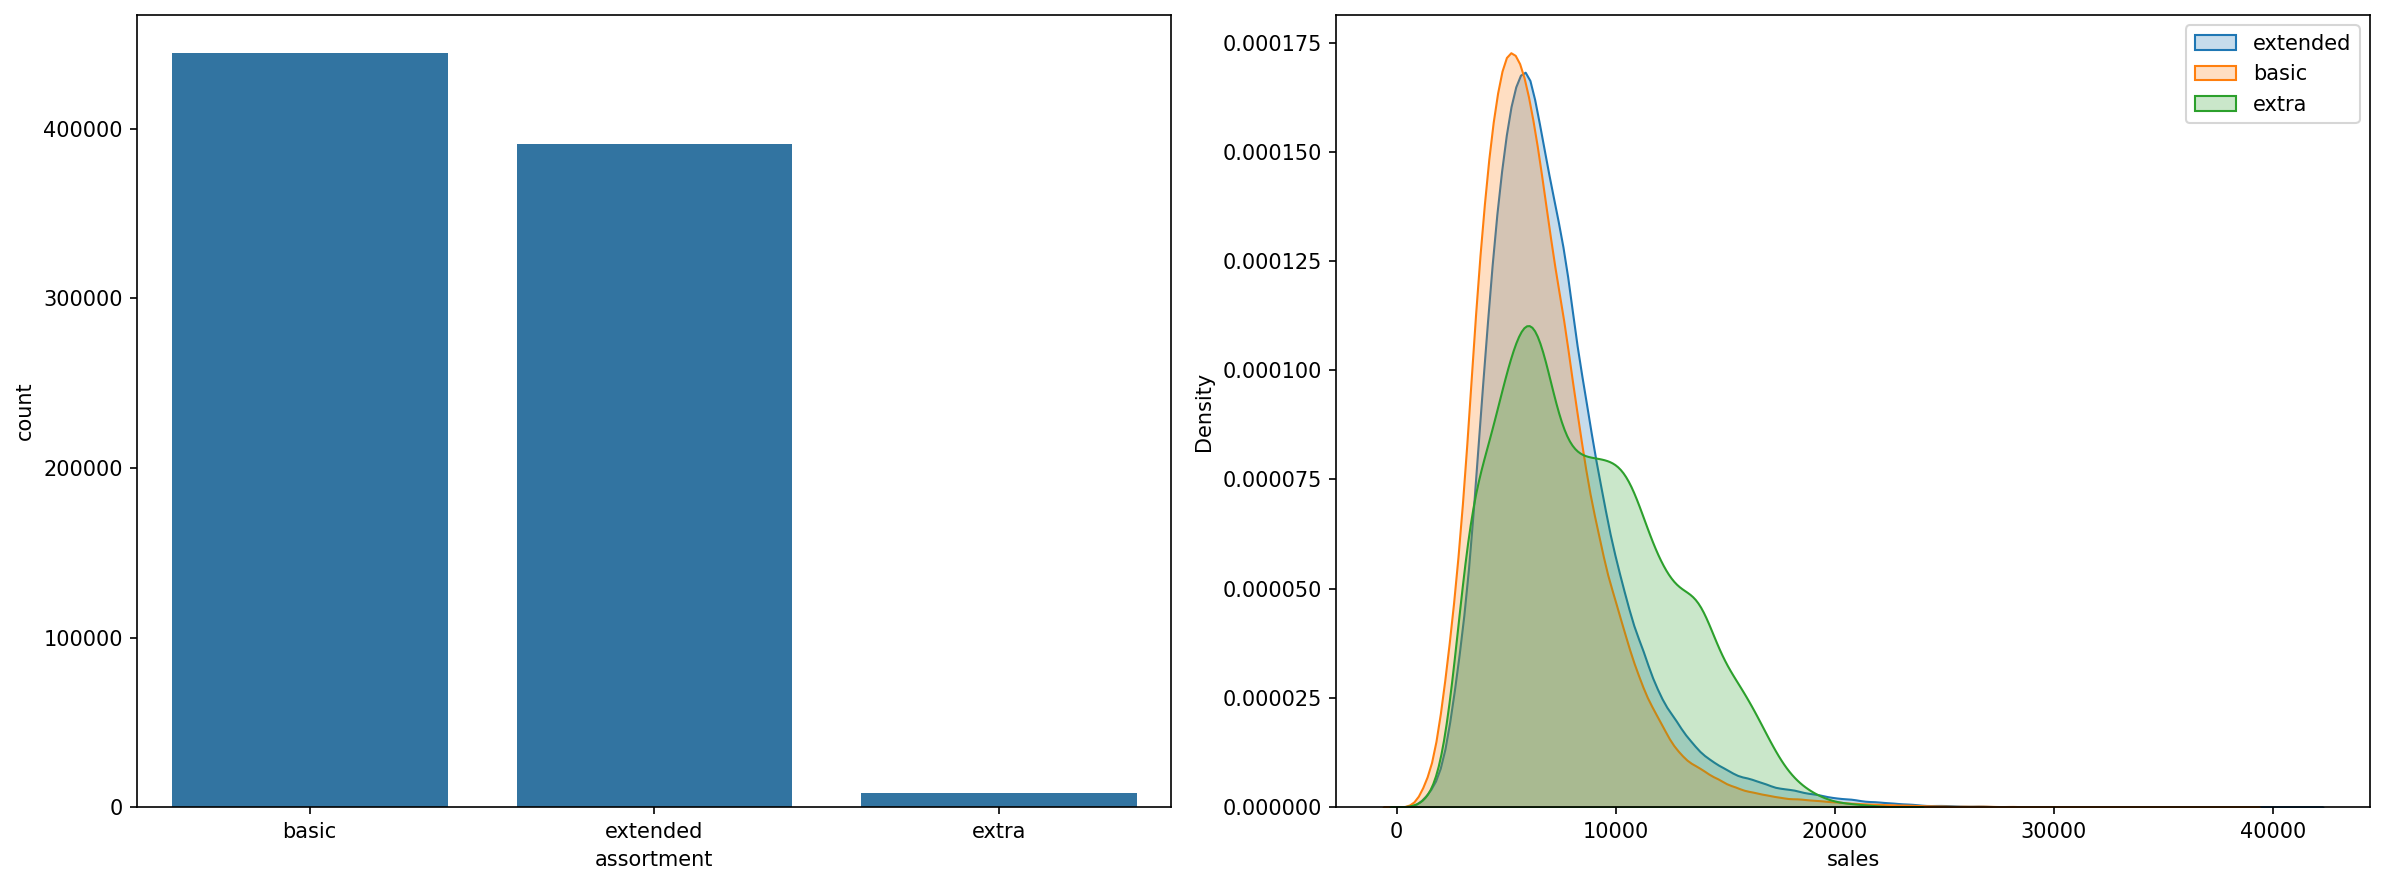

In [29]:
# state_holiday
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
a = df4[df4['state_holiday'] != 'regular_day']
sns.countplot(x='state_holiday', data=a)

plt.subplot(1,2,2)
sns.kdeplot(df4[df4['state_holiday'] == 'public_holiday']['sales'], label='public_holiday', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'easter_holiday']['sales'], label='easter_holiday', fill=True)
sns.kdeplot(df4[df4['state_holiday'] == 'christmas']['sales'], label='christmas', fill=True)
plt.legend()

plt.tight_layout()
plt.show()


# store_type
plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.countplot(x='store_type', data=df4)

plt.subplot(1,2,2)
sns.kdeplot(df4[df4['store_type'] == 'a']['sales'], label='a', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'b']['sales'], label='b', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'c']['sales'], label='c', fill=True)
sns.kdeplot(df4[df4['store_type'] == 'd']['sales'], label='d', fill=True)
plt.legend()

plt.tight_layout()
plt.show()

# assostment

plt.figure(figsize=(16,6))

plt.subplot(1,2,1)
sns.countplot(x='assortment', data=df4)

plt.subplot(1,2,2)
sns.kdeplot(df4[df4['assortment'] == 'extended']['sales'], label='extended', fill=True)
sns.kdeplot(df4[df4['assortment'] == 'basic']['sales'], label='basic', fill=True)
sns.kdeplot(df4[df4['assortment'] == 'extra']['sales'], label='extra', fill=True)
plt.legend()

plt.tight_layout()
plt.show()

## 4.2 Análise bivariada

### H1. Lojas com maior sortimentos deveriam vender mais.

**FALSA** Lojas com maior sortimento vendem menos

<Axes: xlabel='year_week'>

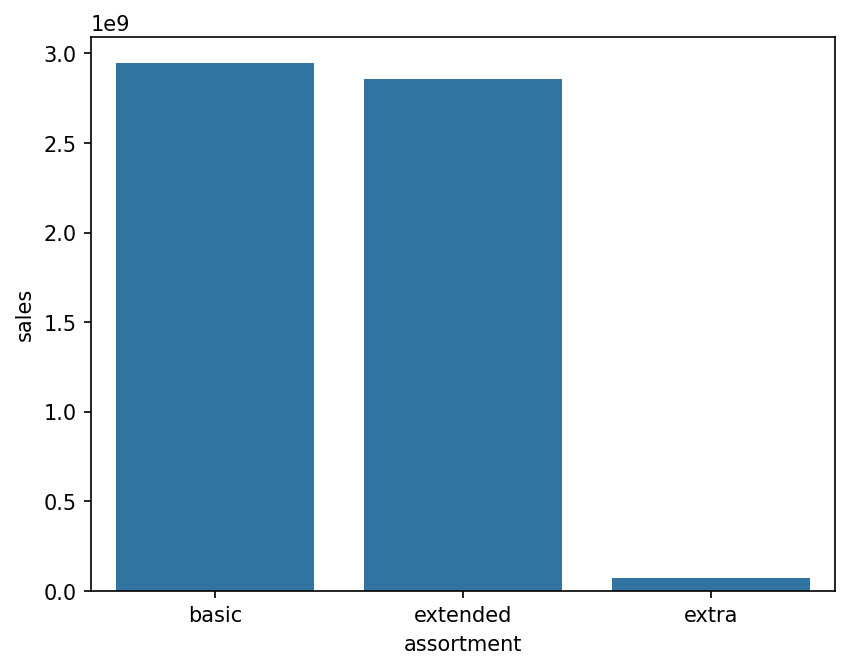

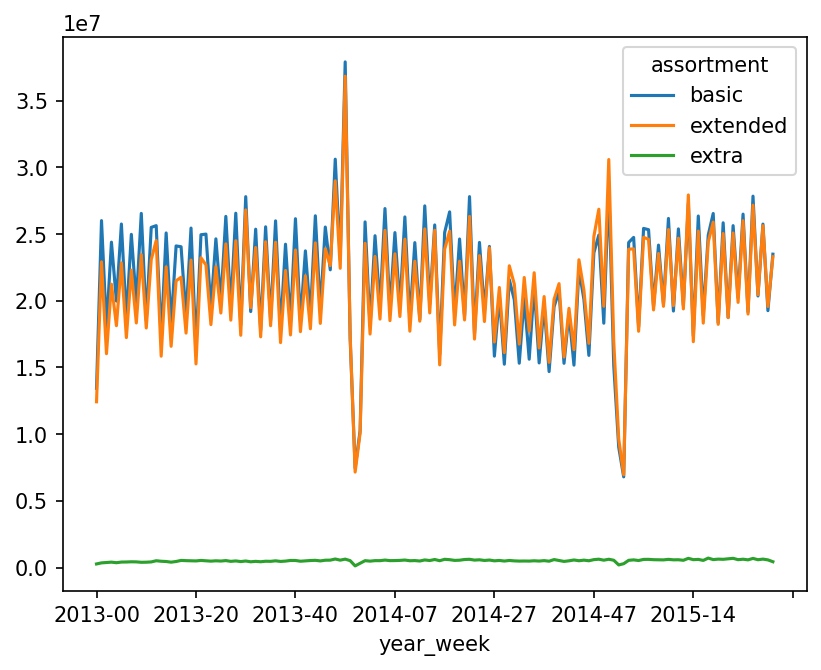

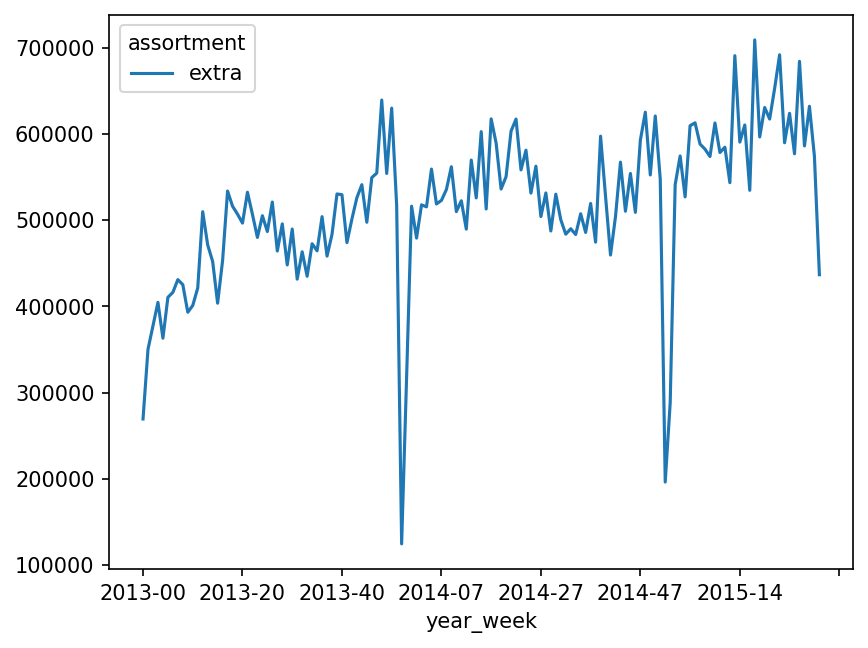

In [30]:
aux1 = df4[['assortment','sales']].groupby('assortment').sum().reset_index()
sns.barplot(x='assortment', y='sales', data=aux1)

aux2 = df4[['year_week','assortment','sales']].groupby(['year_week','assortment']).sum().reset_index()
aux2.pivot(index='year_week', columns='assortment',values='sales').plot()

aux3 = aux2[aux2['assortment'] == 'extra']
aux3.pivot(index='year_week', columns='assortment',values='sales').plot()

### H2. Lojas com competidores mais próximos deveriam vender menos.

**FALSA** Lojas com competidores mais proximos vendem mais

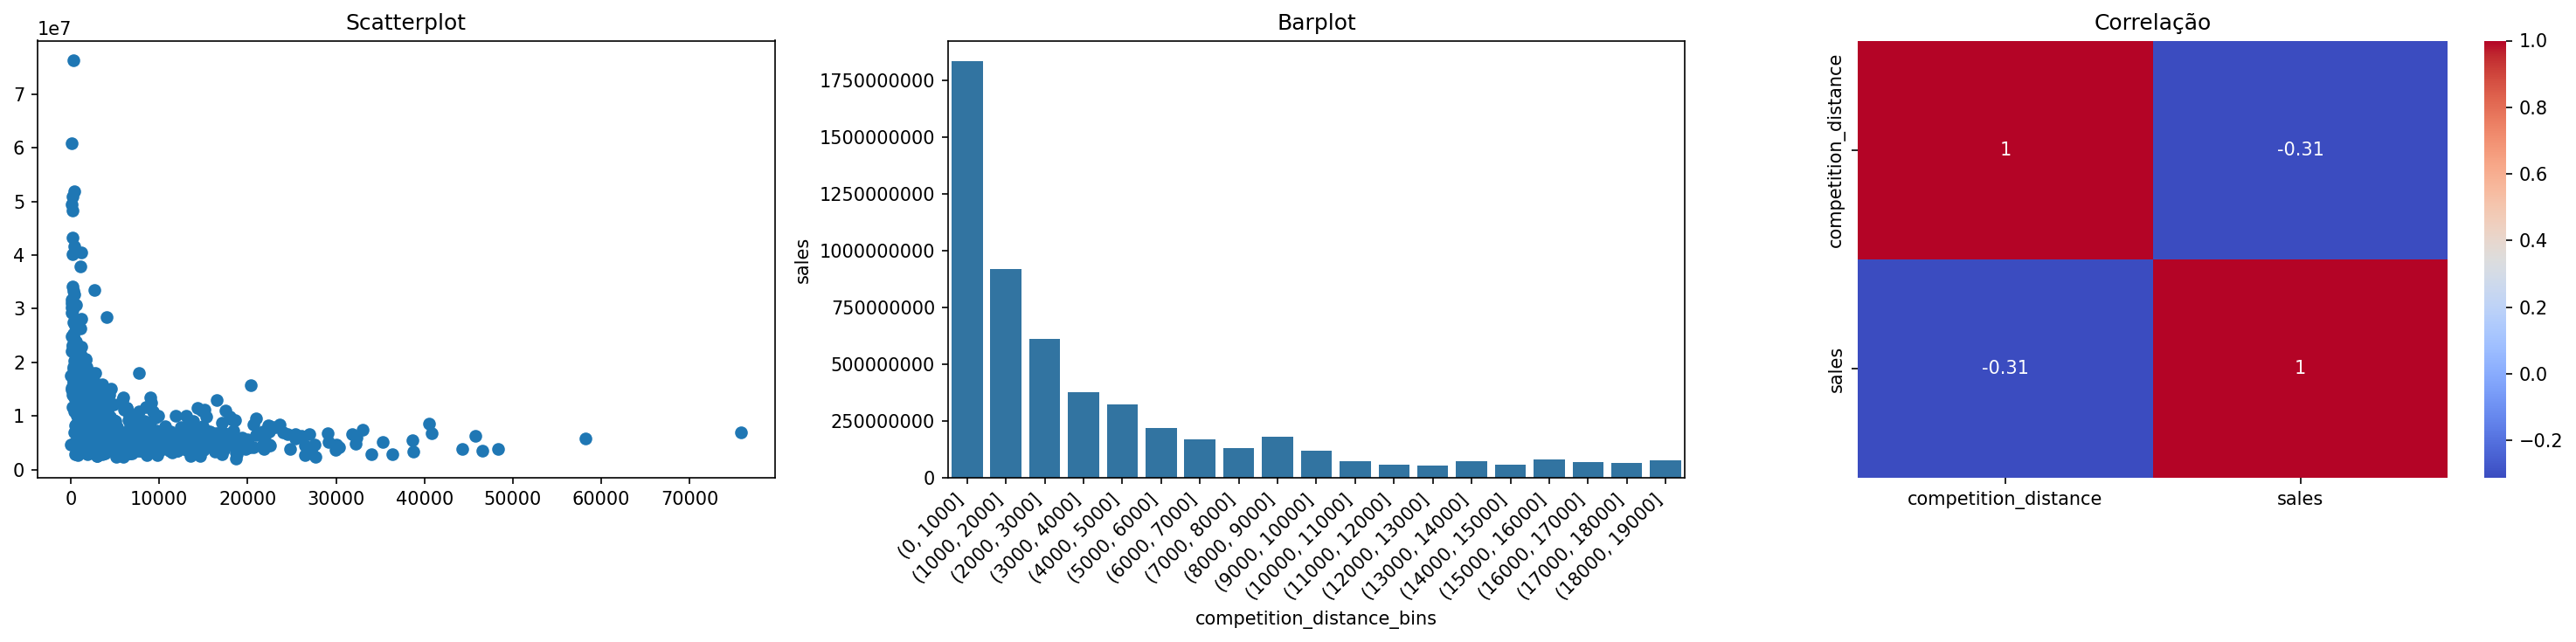

In [31]:
aux4 = df4[['competition_distance', 'sales']].groupby('competition_distance').sum().reset_index()

bins = list(np.arange(0, 20000, 1000))

aux4_bar = aux4.copy()
aux4_bar['competition_distance_bins'] = pd.cut(aux4_bar['competition_distance'], bins=bins)
aux4_bar = aux4_bar[['competition_distance_bins', 'sales']].groupby('competition_distance_bins').sum().reset_index()

plt.figure(figsize=(20, 5))

# gráfico 1
plt.subplot(1, 3, 1)
plt.scatter(x='competition_distance', y='sales', data=aux4)
plt.title('Scatterplot')

# gráfico 2
plt.subplot(1, 3, 2)
sns.barplot(data=aux4_bar, x='competition_distance_bins', y='sales')
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Barplot')

# gráfico 3
plt.subplot(1, 3, 3)
sns.heatmap(aux4[['competition_distance', 'sales']].corr(method='pearson'), annot=True, cmap='coolwarm')
plt.title('Correlação')

plt.tight_layout()
plt.show()

### H3. Lojas com competidores à mais tempo deveriam vendem mais.

**FALSA** Lojas com competidores á mais tempo vendem menos

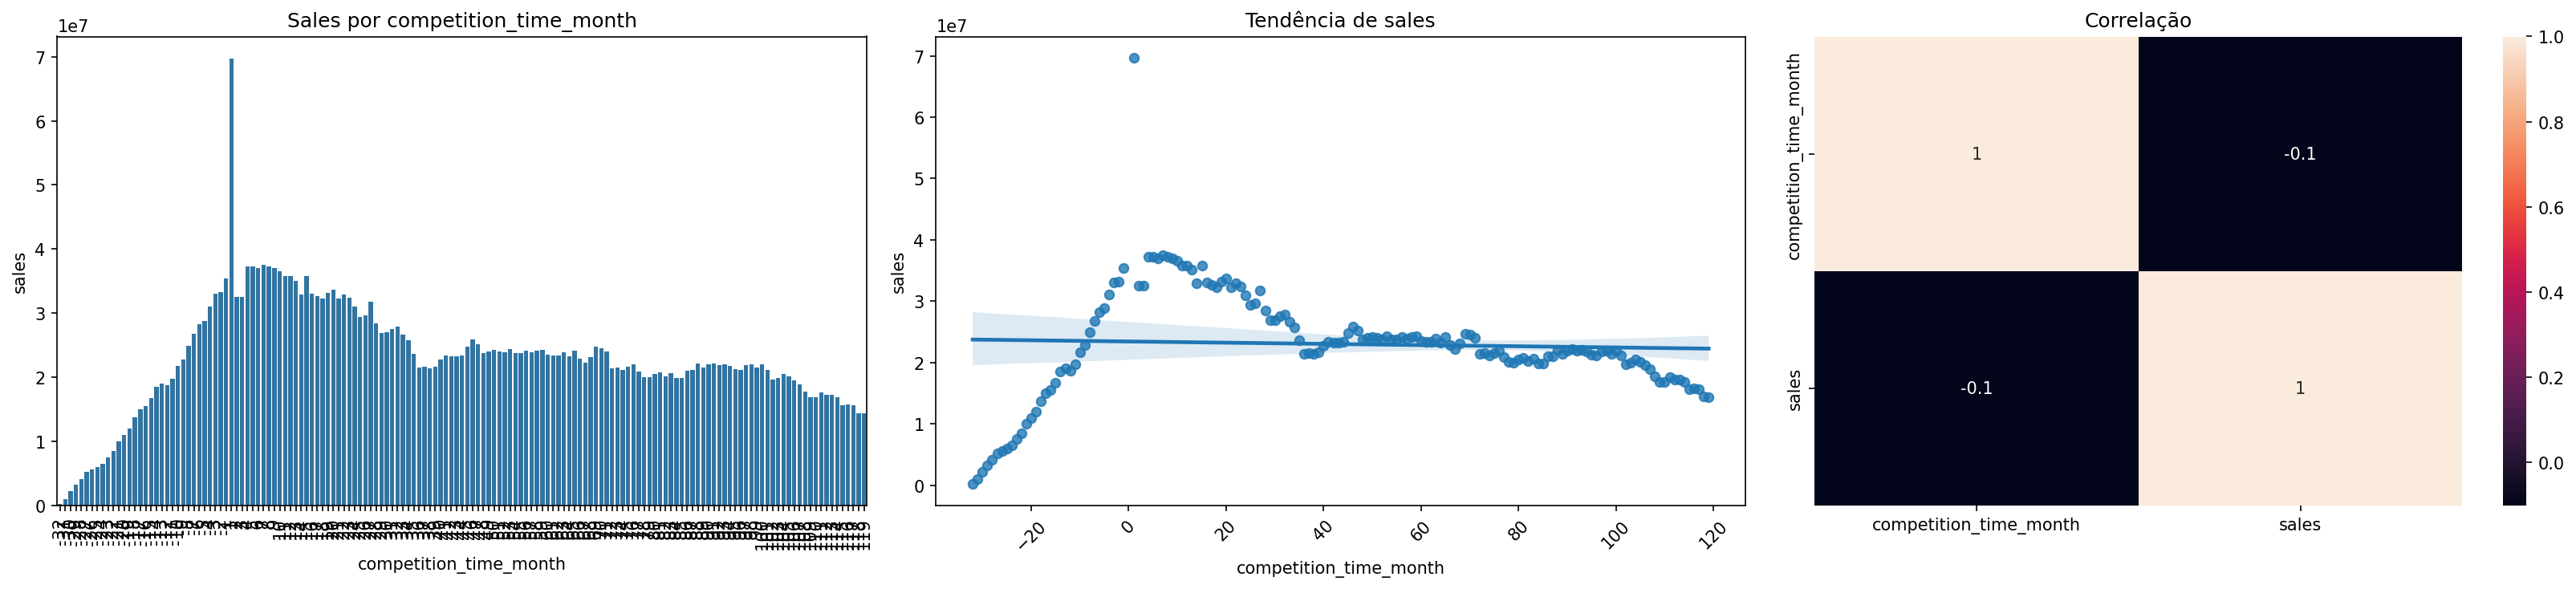

In [32]:
aux5 = (df4[['competition_time_month', 'sales']].groupby('competition_time_month', as_index=False).sum())

aux6 = aux5[(aux5['competition_time_month'] < 120) & (aux5['competition_time_month'] != 0)].sort_values('competition_time_month')

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.barplot(x='competition_time_month', y='sales', data=aux6, ax=axes[0])
axes[0].set_title('Sales por competition_time_month')
axes[0].tick_params(axis='x', rotation=90)

sns.regplot(x='competition_time_month', y='sales', data=aux6, ax=axes[1], scatter_kws={'s': 30})
axes[1].set_title('Tendência de sales')
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(aux5.corr(method='pearson'), annot=True, ax=axes[2])
axes[2].set_title('Correlação')

plt.tight_layout()
plt.show()

In [33]:
df4.columns

Index(['store', 'day_of_week', 'date', 'sales', 'promo', 'state_holiday',
       'school_holiday', 'store_type', 'assortment', 'competition_distance',
       'competition_open_since_month', 'competition_open_since_year', 'promo2',
       'promo2_since_week', 'promo2_since_year', 'is_promo', 'year', 'month',
       'day', 'week_of_year', 'year_week', 'competition_since',
       'competition_time_month', 'promo_since', 'promo_time_week'],
      dtype='str')

### H4. Lojas com promoções ativas por mais tempo deveriam vender mais.

**FALSA** Lojas com promoções ativas por mais tempo vendem menos, depois de um certo periodo de tempo

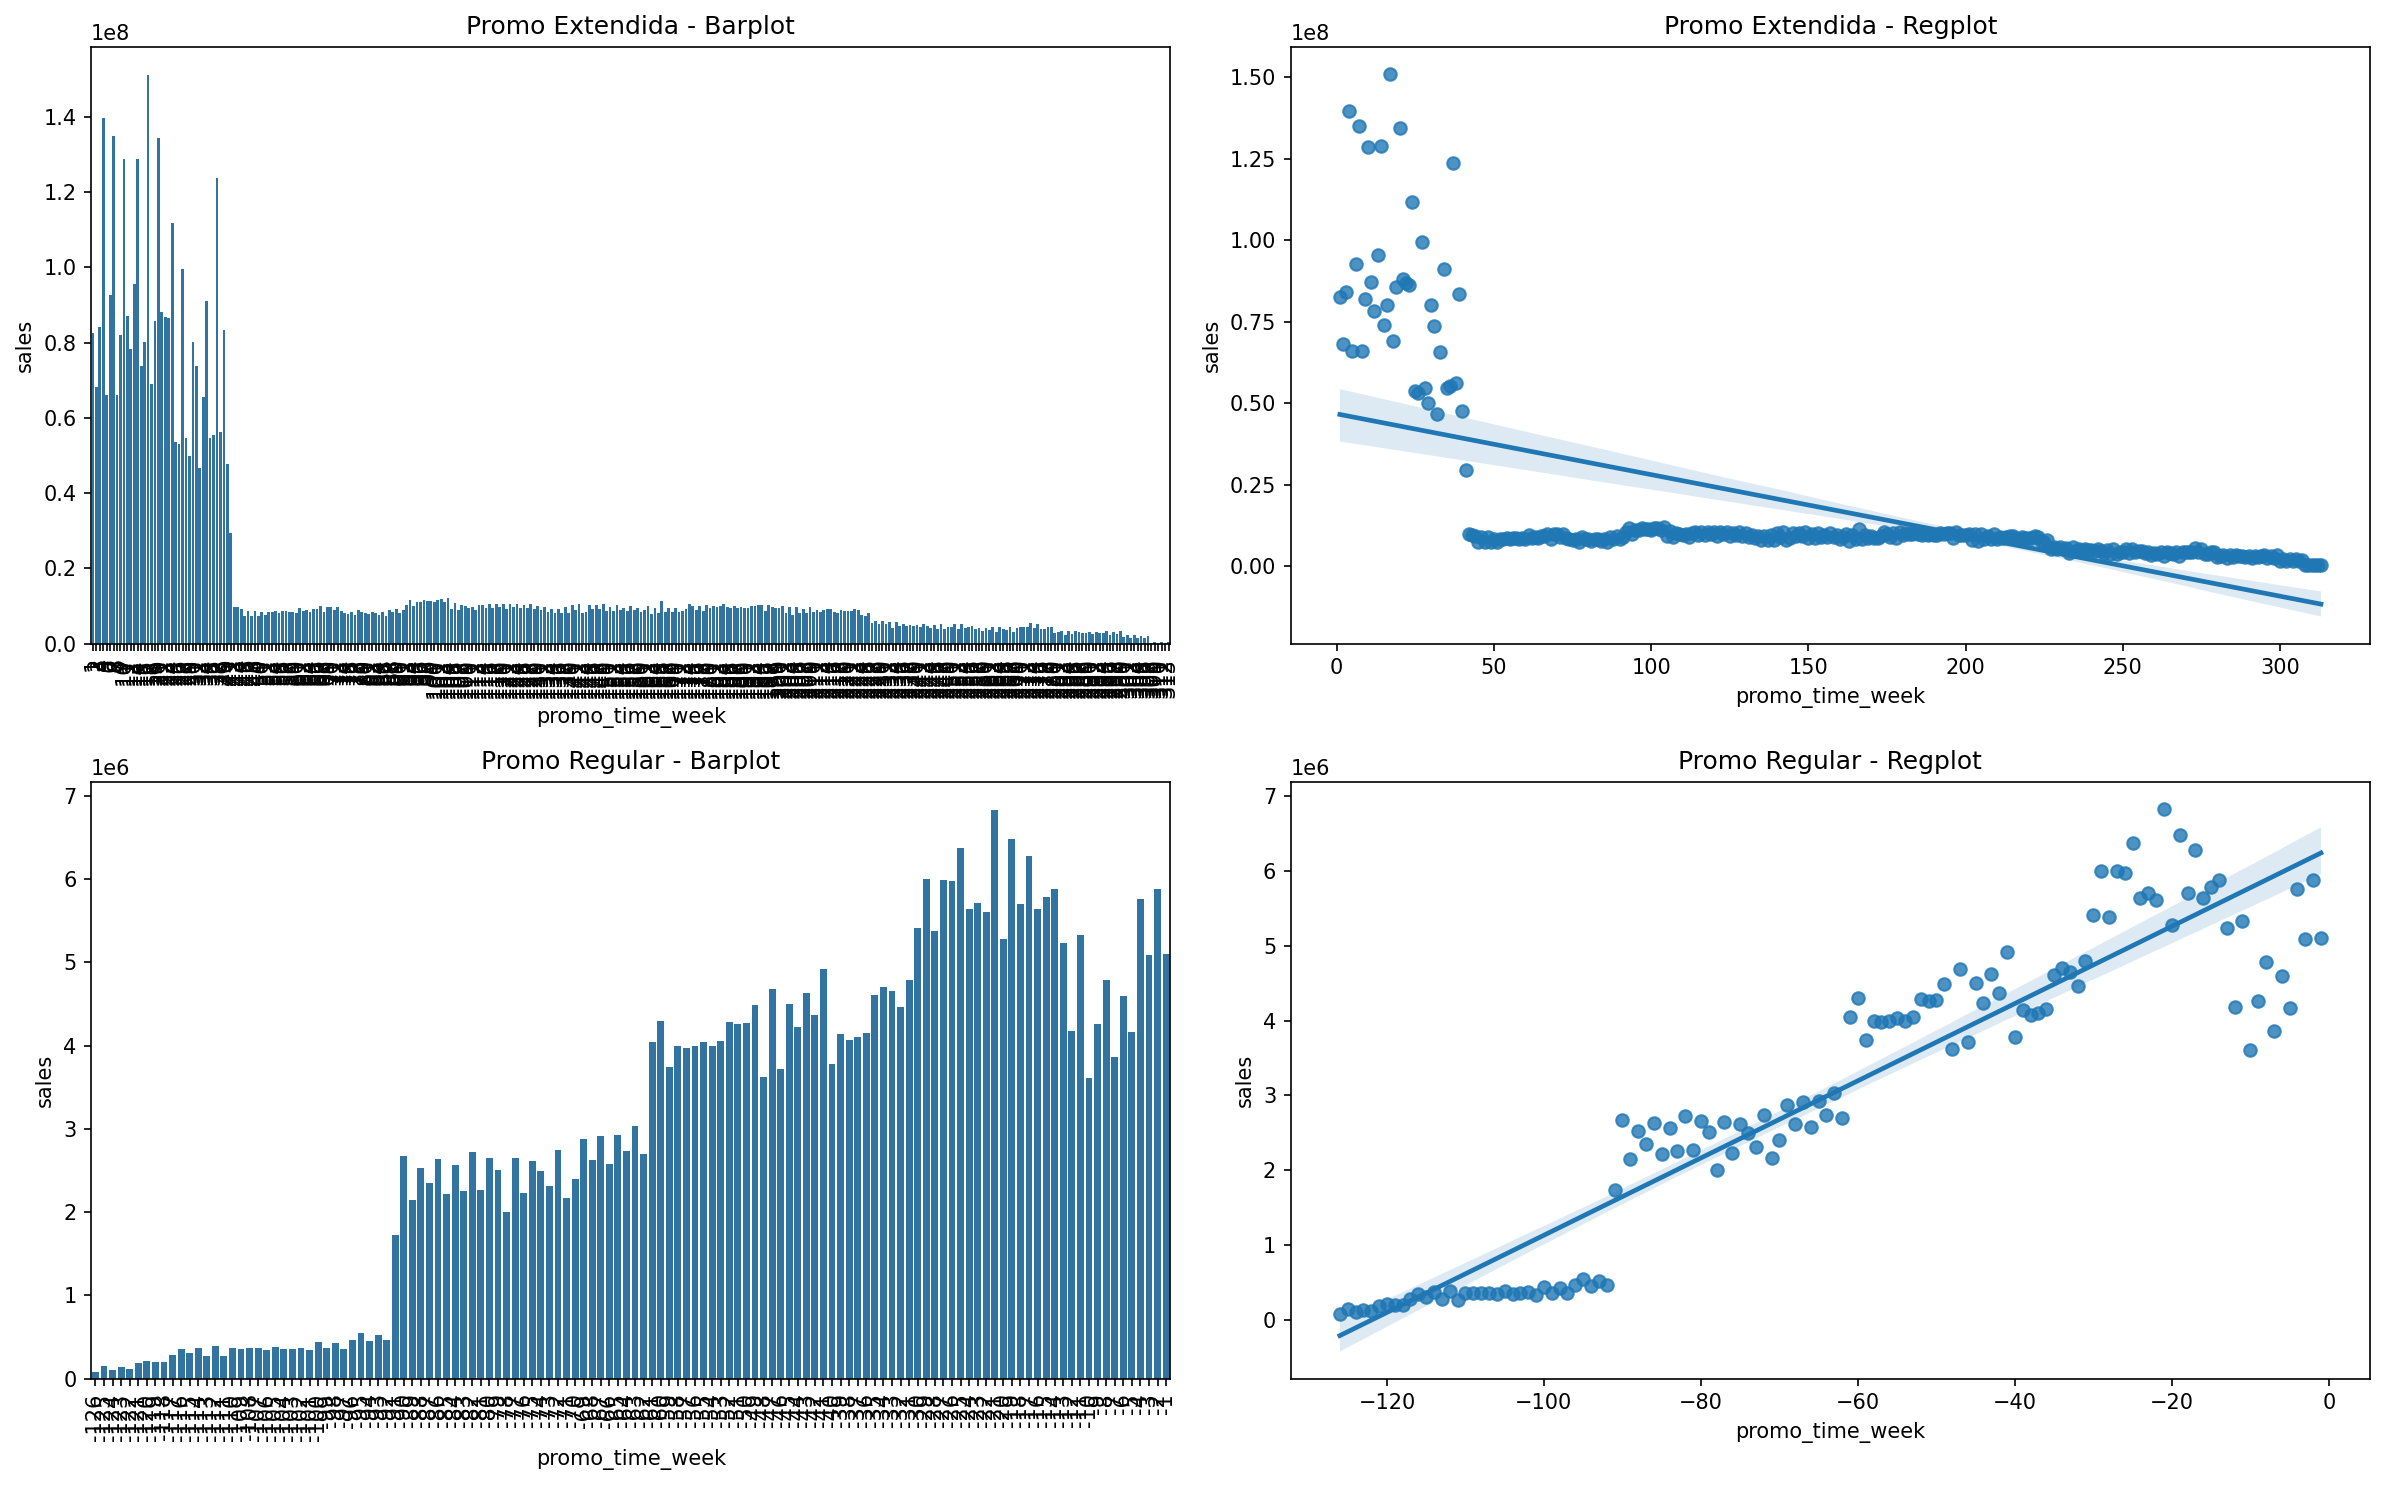

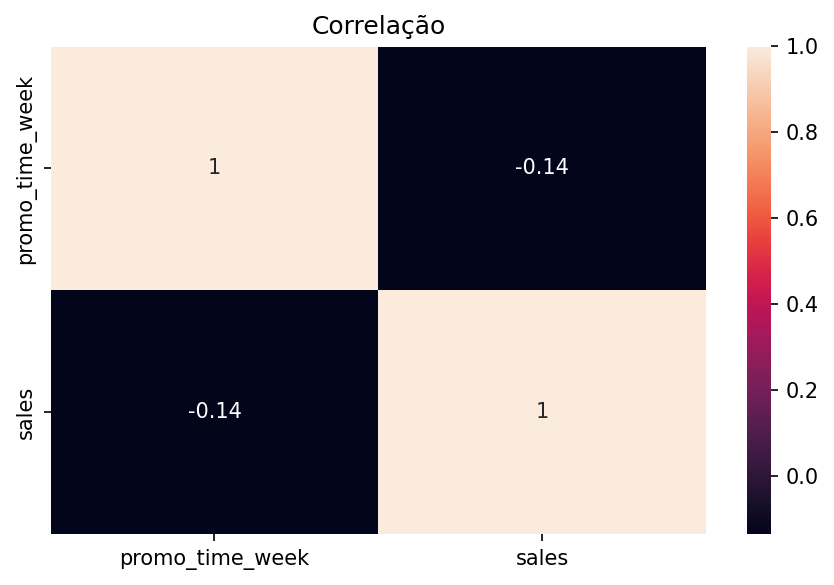

In [34]:
aux1 = df4[['promo_time_week', 'sales']].groupby('promo_time_week').sum().reset_index()

aux2 = aux1[aux1['promo_time_week'] > 0]  # promo extendida
aux3 = aux1[aux1['promo_time_week'] < 0]  # promo regular

plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.barplot(x='promo_time_week', y='sales', data=aux2)
plt.xticks(rotation=90)
plt.title('Promo Extendida - Barplot')

plt.subplot(2, 2, 2)
sns.regplot(x='promo_time_week', y='sales', data=aux2)
plt.title('Promo Extendida - Regplot')

plt.subplot(2, 2, 3)
sns.barplot(x='promo_time_week', y='sales', data=aux3)
plt.xticks(rotation=90)
plt.title('Promo Regular - Barplot')

plt.subplot(2, 2, 4)
sns.regplot(x='promo_time_week', y='sales', data=aux3)
plt.title('Promo Regular - Regplot')

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(aux1.corr(method='pearson'), annot=True)
plt.title('Correlação')
plt.tight_layout()
plt.show()

In [35]:
df4

,store,day_of_week,date,sales,promo,state_holiday,school_holiday,store_type,assortment,competition_distance,...,is_promo,year,month,day,week_of_year,year_week,competition_since,competition_time_month,promo_since,promo_time_week
0,1,5,2015-07-31,5263,1,regular_day,1,c,basic,1270.0,...,0,2015,7,31,31,2015-30,2008-09-01,84,2015-02-09,24
1,2,5,2015-07-31,6064,1,regular_day,1,a,basic,570.0,...,1,2015,7,31,31,2015-30,2007-11-01,94,2010-03-22,279
2,3,5,2015-07-31,8314,1,regular_day,1,a,basic,14130.0,...,1,2015,7,31,31,2015-30,2006-12-01,105,2011-03-28,226
3,4,5,2015-07-31,13995,1,regular_day,1,c,extended,620.0,...,0,2015,7,31,31,2015-30,2009-09-01,71,2015-02-09,24
4,5,5,2015-07-31,4822,1,regular_day,1,a,basic,29910.0,...,0,2015,7,31,31,2015-30,2015-04-01,4,2015-02-09,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,0,public_holiday,1,b,basic,150.0,...,0,2013,1,1,1,2013-00,2006-09-01,77,2012-12-31,0
1016827,733,2,2013-01-01,10765,0,public_holiday,1,b,extra,860.0,...,0,2013,1,1,1,2013-00,1999-10-01,161,2012-12-31,0
1016863,769,2,2013-01-01,5035,0,public_holiday,1,b,extra,840.0,...,1,2013,1,1,1,2013-00,2013-01-01,0,2012-11-19,6
1017042,948,2,2013-01-01,4491,0,public_holiday,1,b,extra,1430.0,...,0,2013,1,1,1,2013-00,2013-01-01,0,2012-12-31,0


### <s>H5. Lojas com mais dias de promoção deveriam vender mais.

### H6. Lojas com mais promoções consecutivas deveriam vender mais.

**FALSA** Lojas com mais promoções consecutivas vendem menos

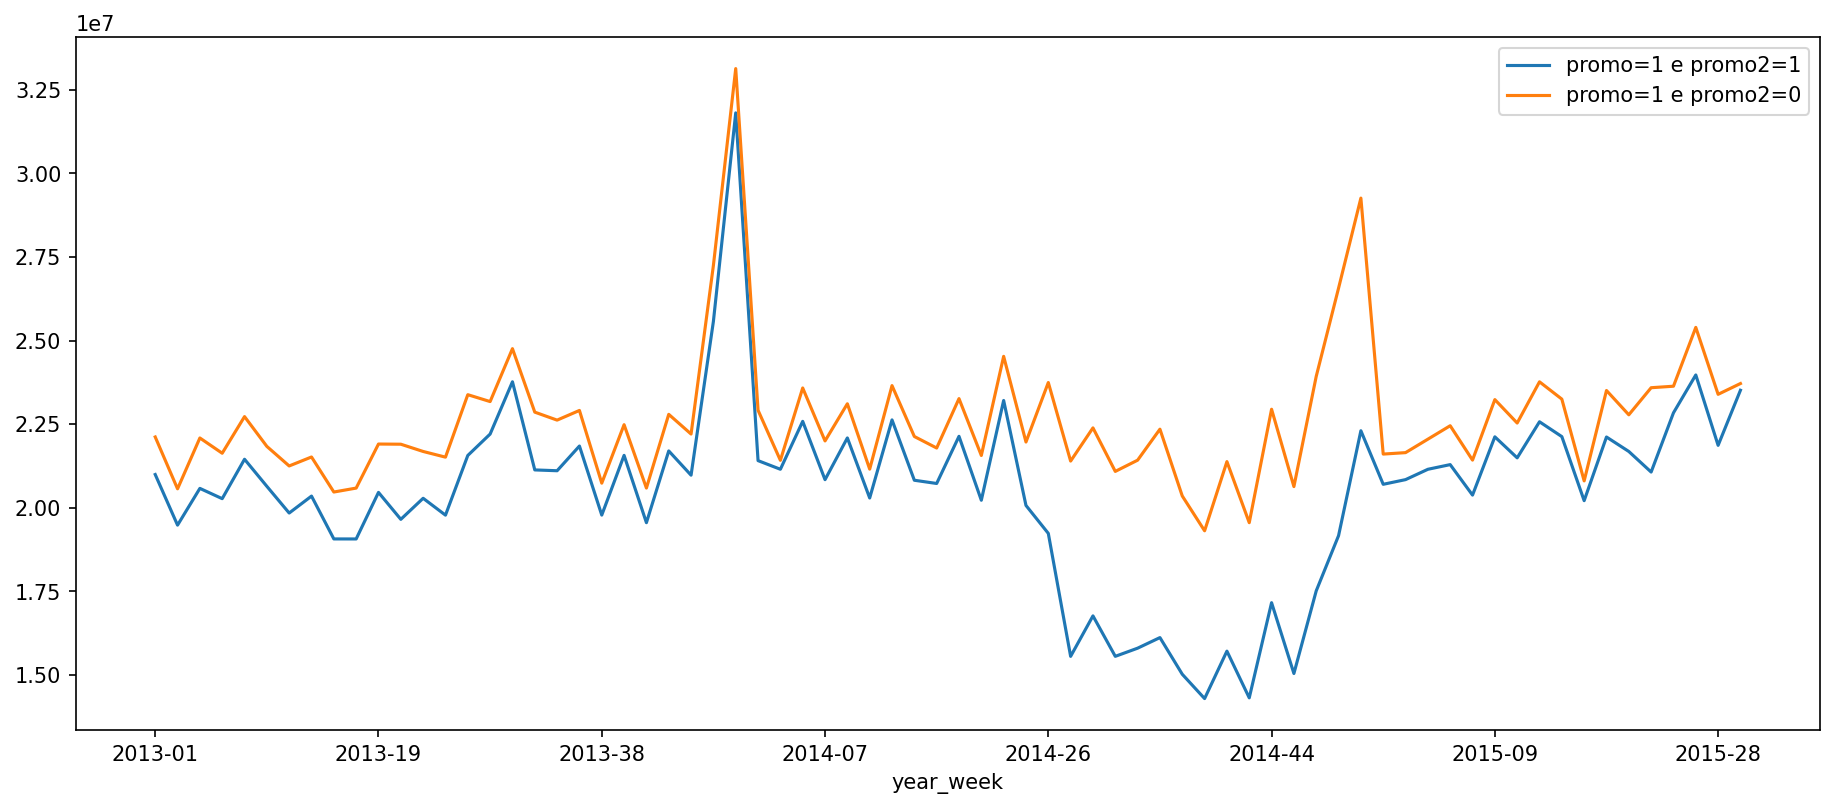

In [36]:
aux1 = df4[(df4['promo'] == 1) & (df4['promo2'] == 1)][['year_week', 'sales']].groupby('year_week').sum().reset_index()
aux2 = df4[(df4['promo'] == 1) & (df4['promo2'] == 0)][['year_week', 'sales']].groupby('year_week').sum().reset_index()

ax = aux1.plot(x='year_week', y='sales', figsize=(15, 6), label='promo=1 e promo2=1')
aux2.plot(x='year_week', y='sales', ax=ax, label='promo=1 e promo2=0')

plt.show()

### H7. Lojas abertas durante o feriado de Natal deveriam vender mais.

**FALSA** Lojas abertas durante o feriado de natal vendem menos

<Axes: xlabel='state_holiday', ylabel='sales'>

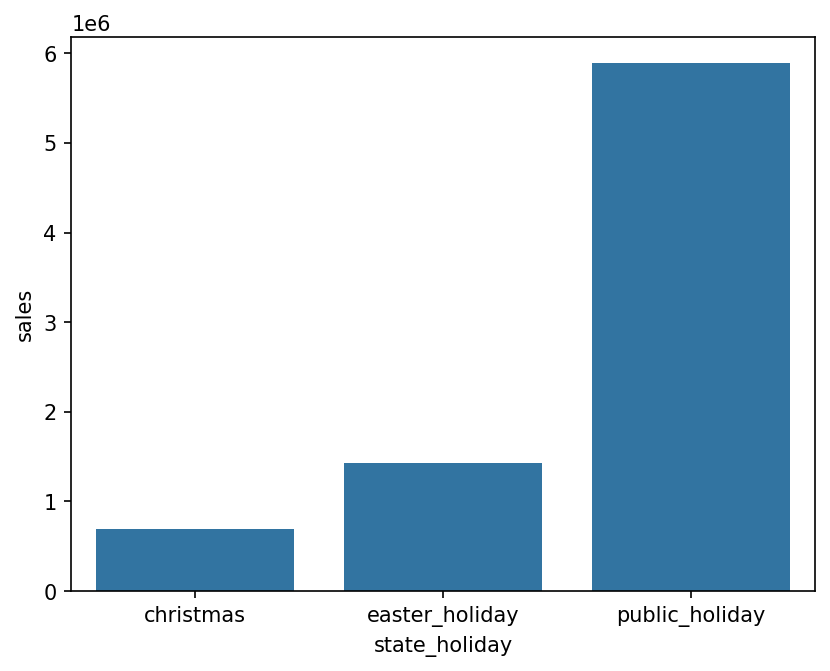

In [37]:
aux = df4[df4['state_holiday'] != 'regular_day']
aux1 = aux[['state_holiday','sales']].groupby('state_holiday').sum().reset_index()
sns.barplot(x='state_holiday' , y='sales' , data=aux1)

### H8. Lojas deveriam vender mais ao longo dos anos.

**FALSA** Lojas vendem menos ao longo dos anos

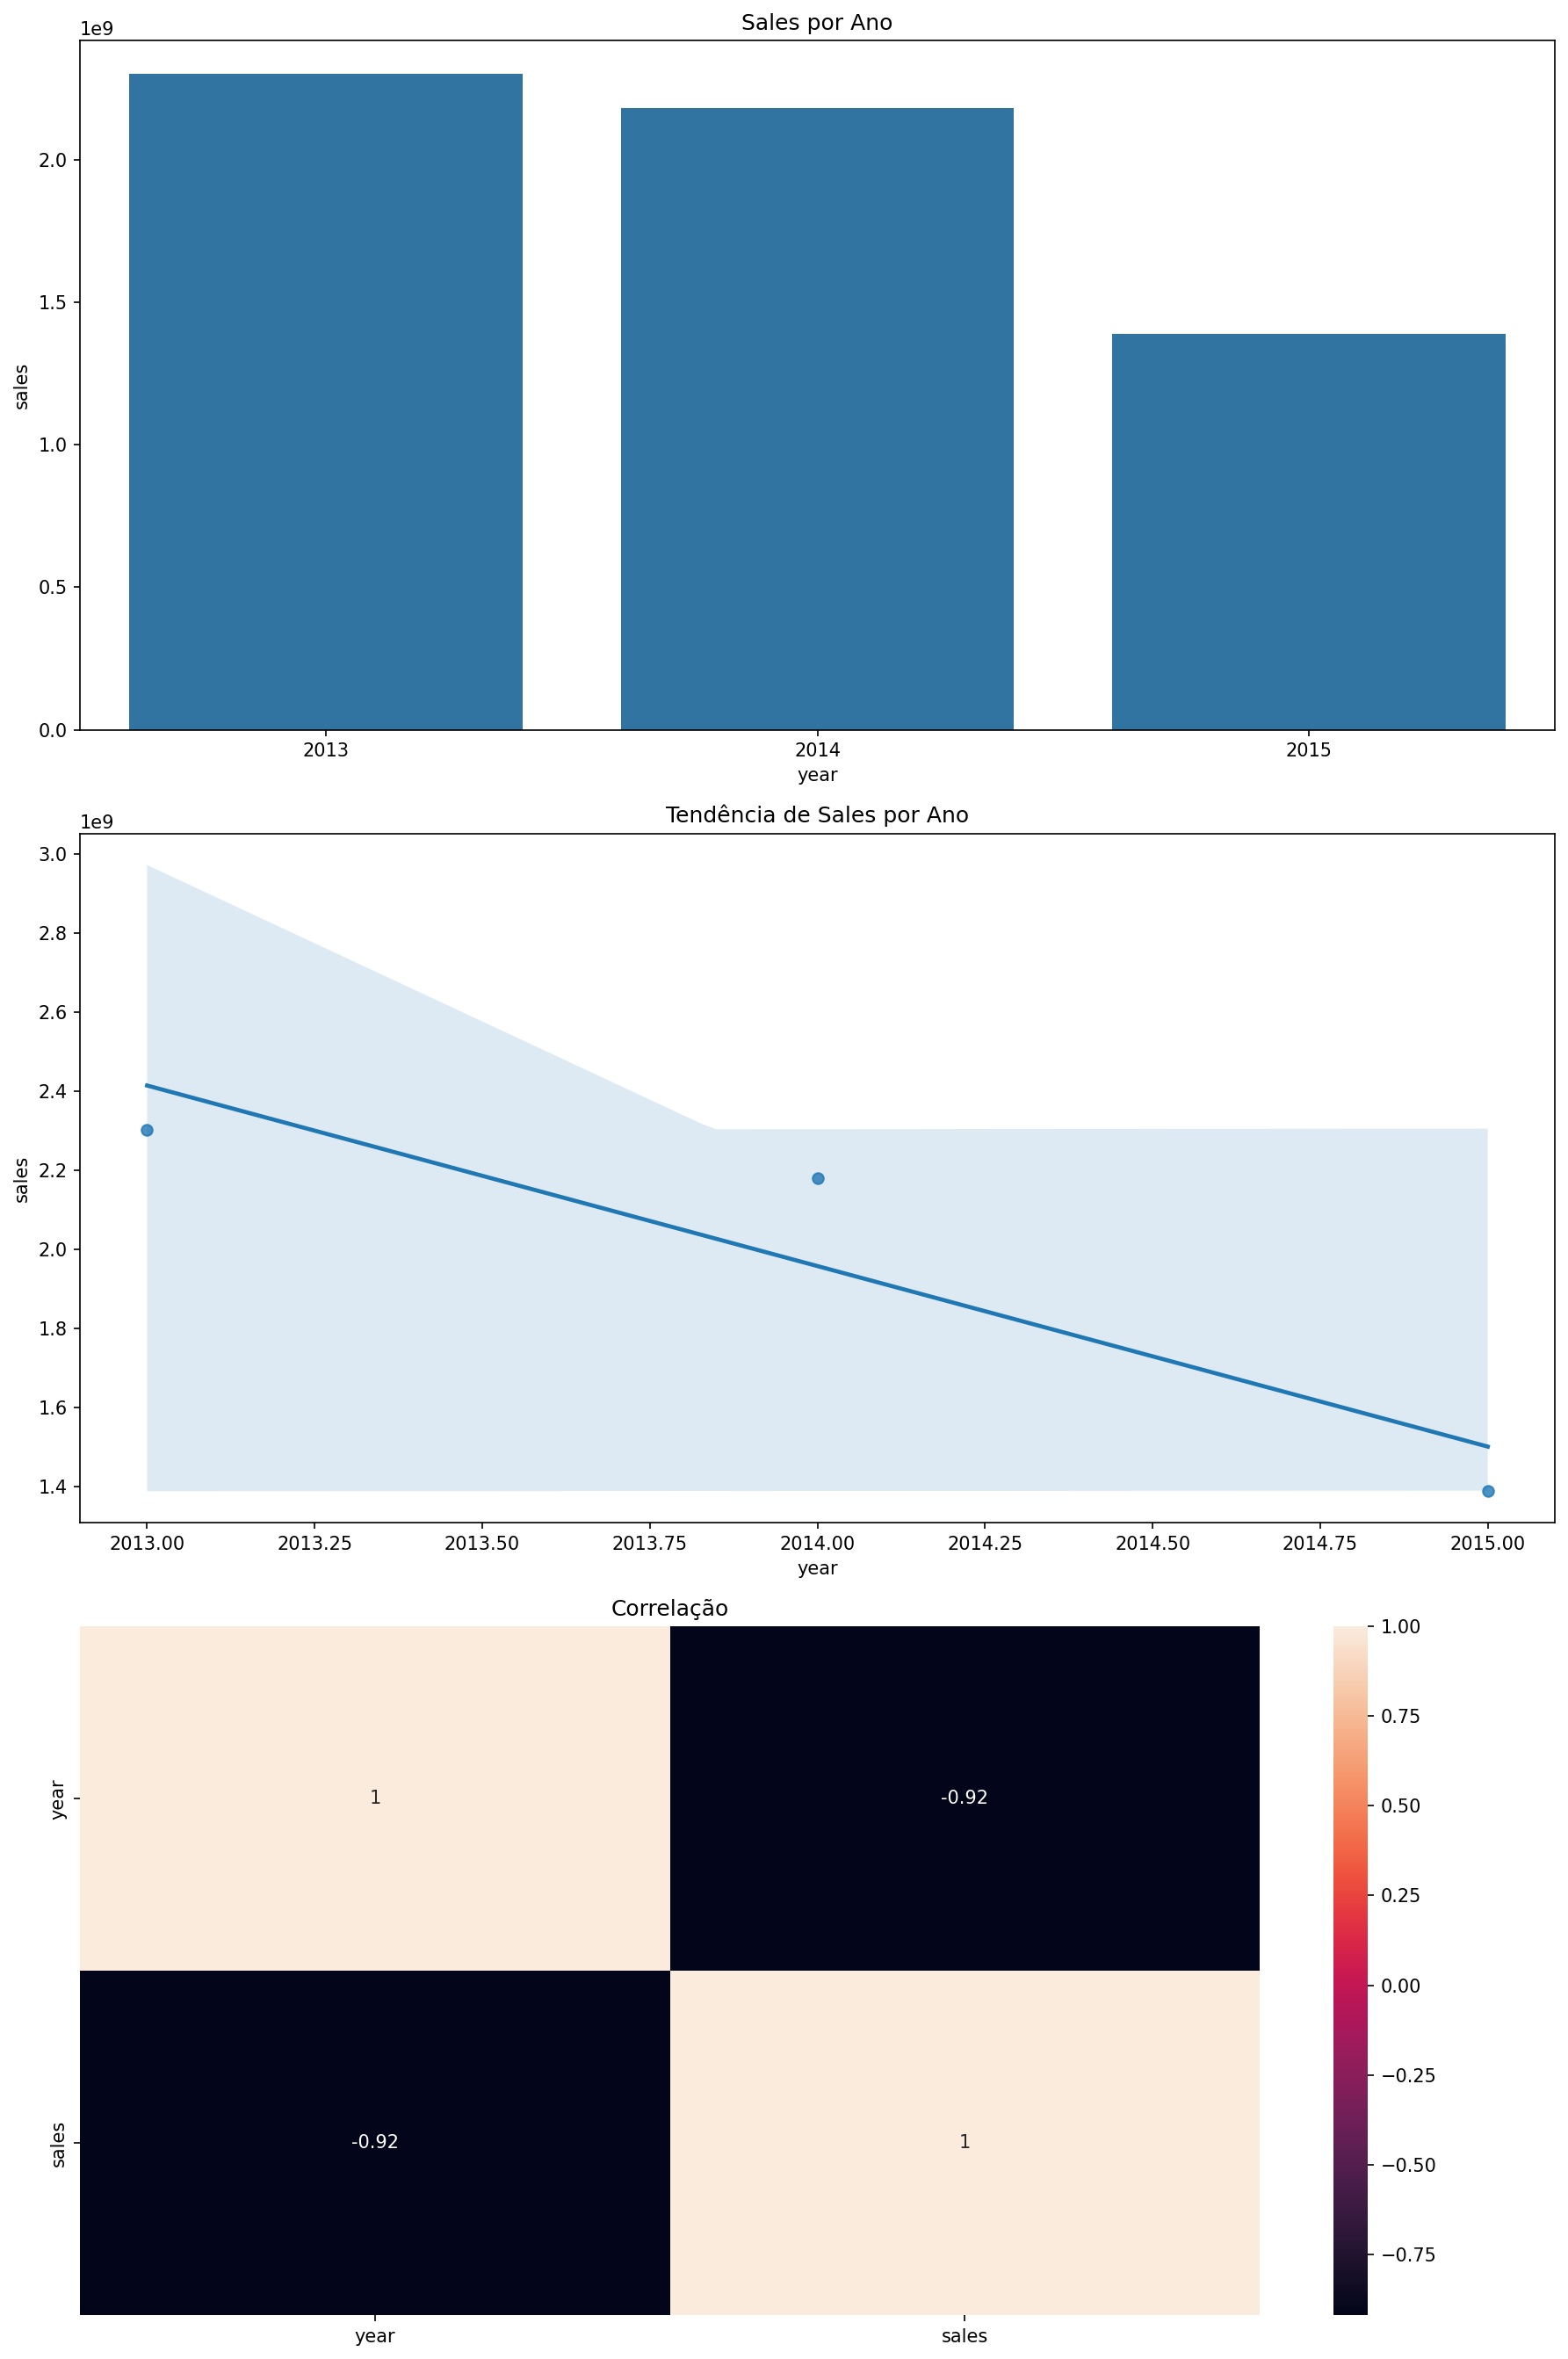

In [38]:
aux1 = df4[['year','sales']].groupby('year').sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.barplot(x='year', y='sales', data=aux1, ax=axes[0])
axes[0].set_title('Sales por Ano')

sns.regplot(x='year', y='sales', data=aux1, ax=axes[1])
axes[1].set_title('Tendência de Sales por Ano')

sns.heatmap(aux1.corr(method='pearson'), annot=True, ax=axes[2])
axes[2].set_title('Correlação')

plt.tight_layout()
plt.show()

### H9. Lojas deveriam vender mais no segundo semestre do ano.

**FALSA** Lojas vendem menos no segundo semestre do ano

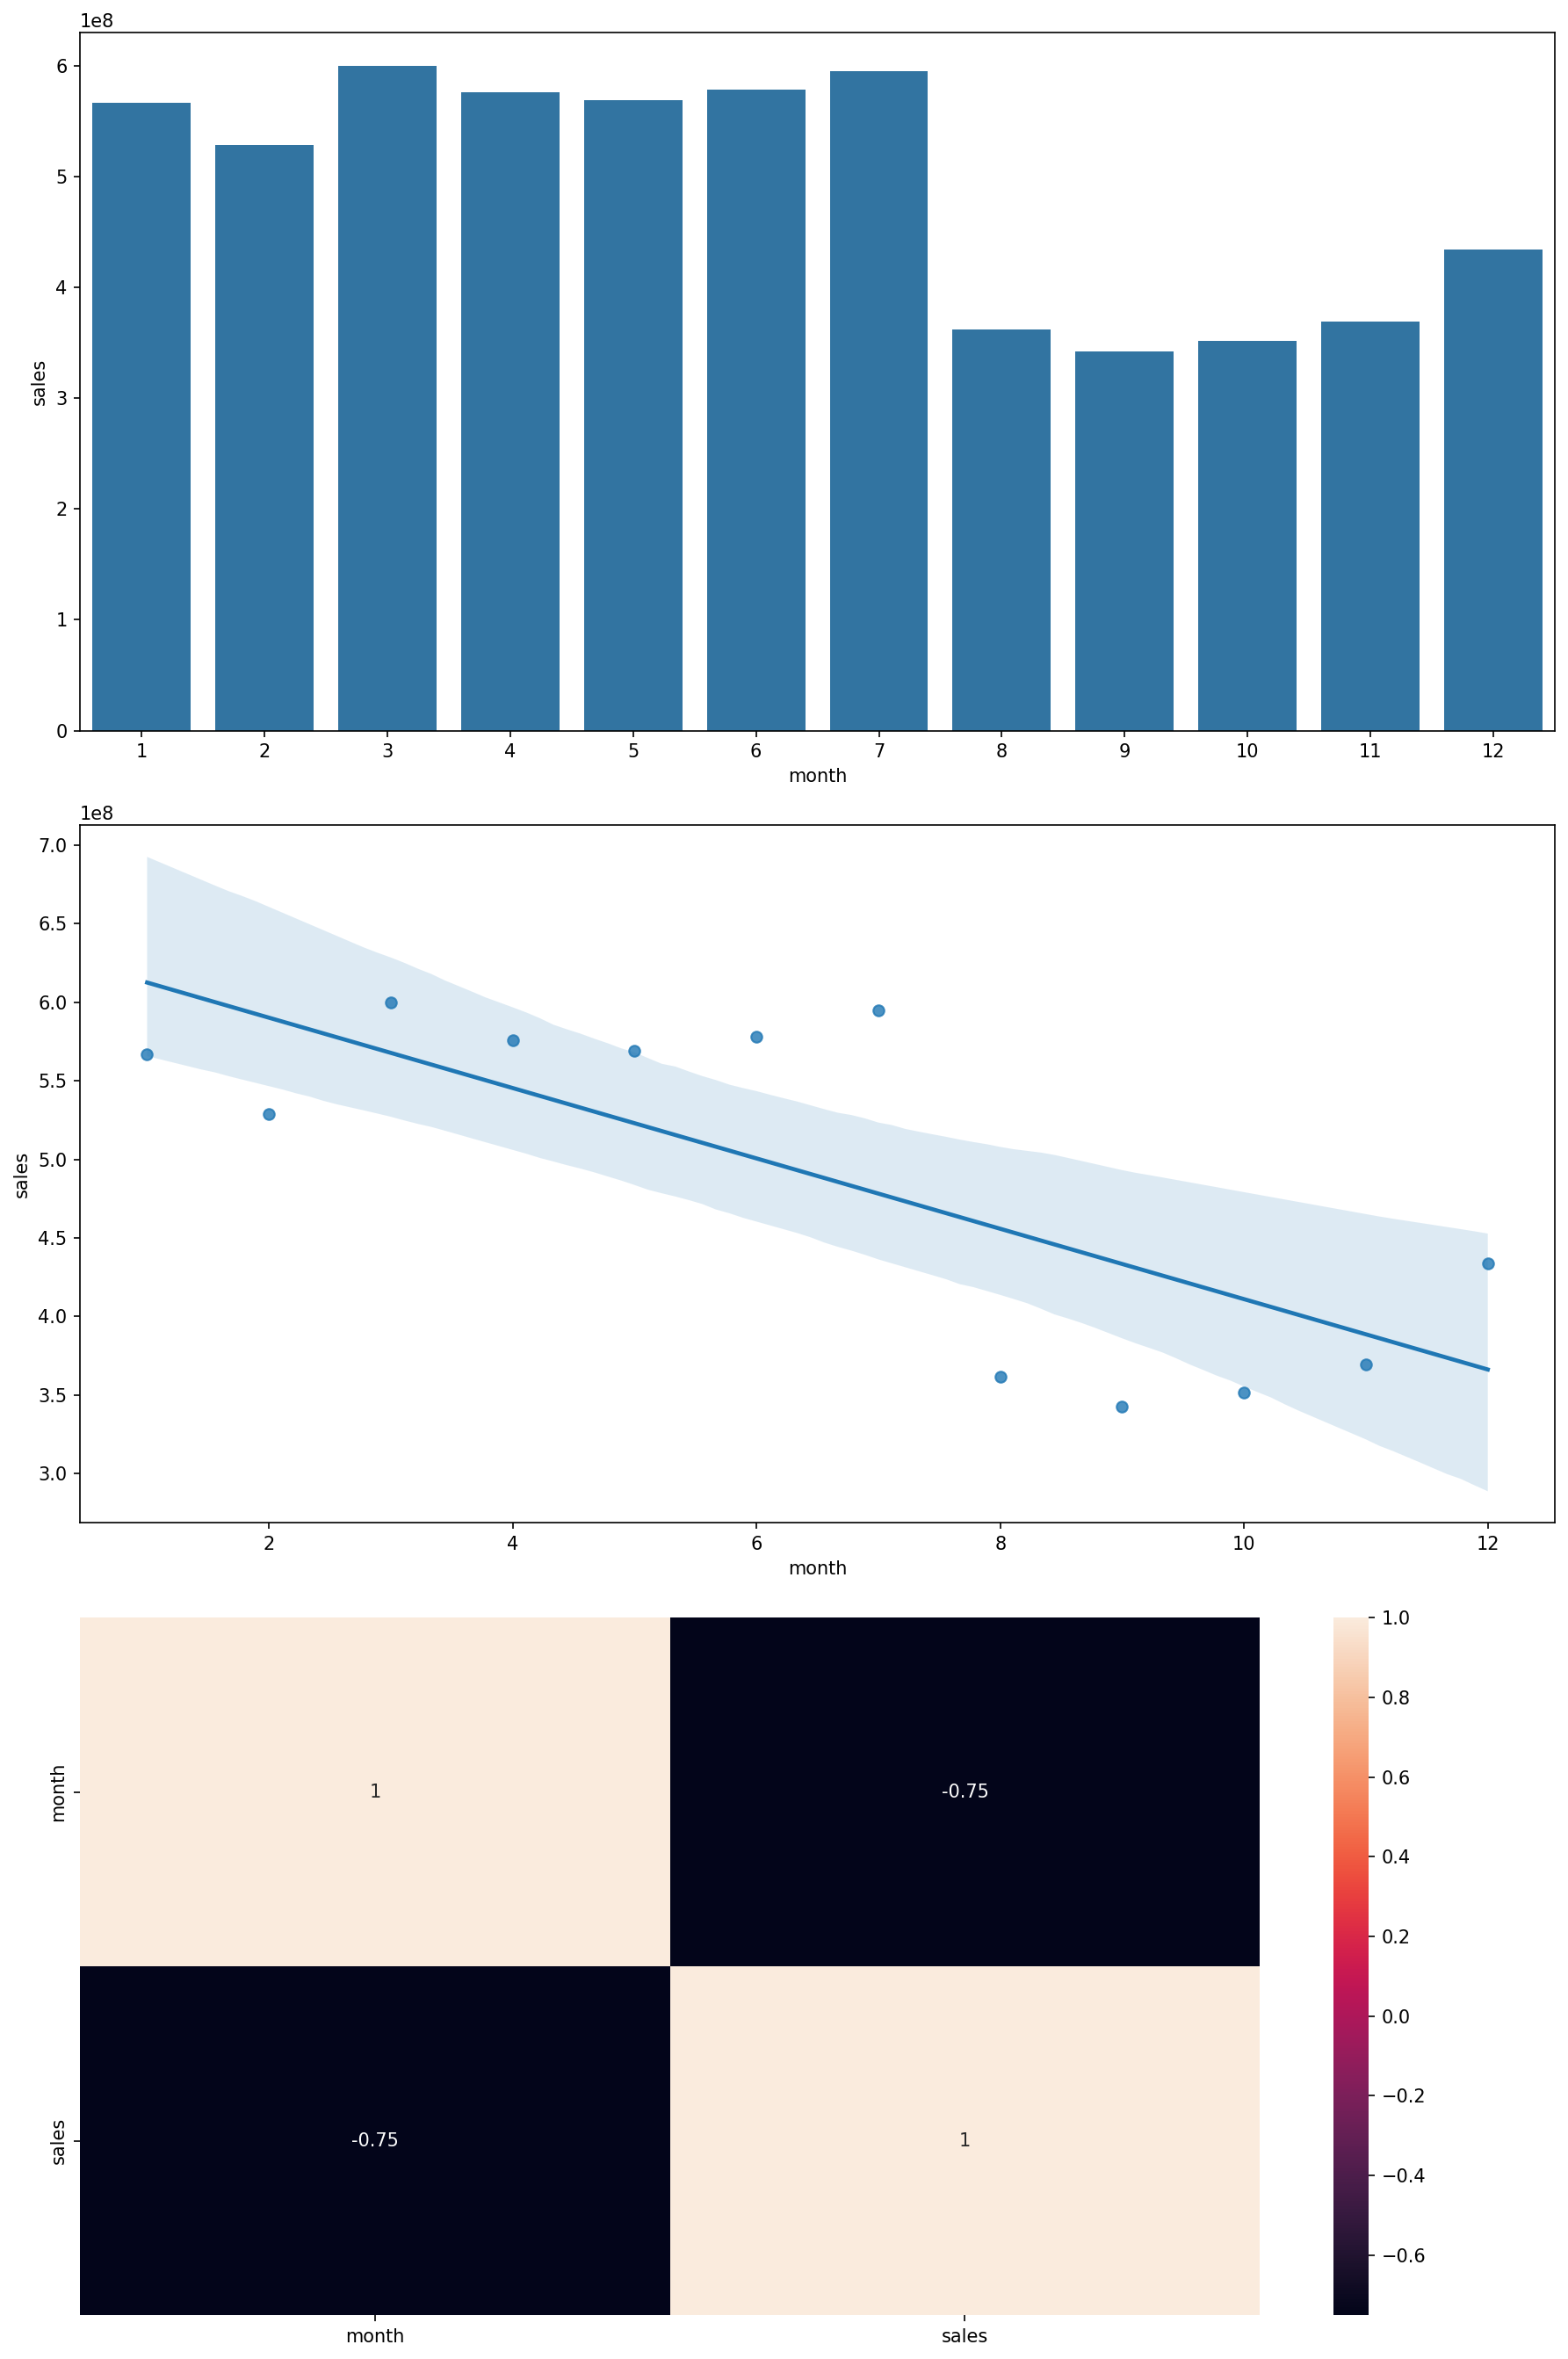

In [39]:
aux1 = df4[['month', 'sales']].groupby('month').sum().reset_index()

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.barplot(x='month', y='sales', data=aux1)

plt.subplot(3, 1, 2)
sns.regplot(x='month', y='sales', data=aux1)

plt.subplot(3, 1, 3)
sns.heatmap(aux1.corr(method='pearson'), annot=True)

plt.tight_layout()
plt.show()

### H10. Lojas deveriam vender mais depois do dia 10 de cada mês.

**VERDADEIRA** 

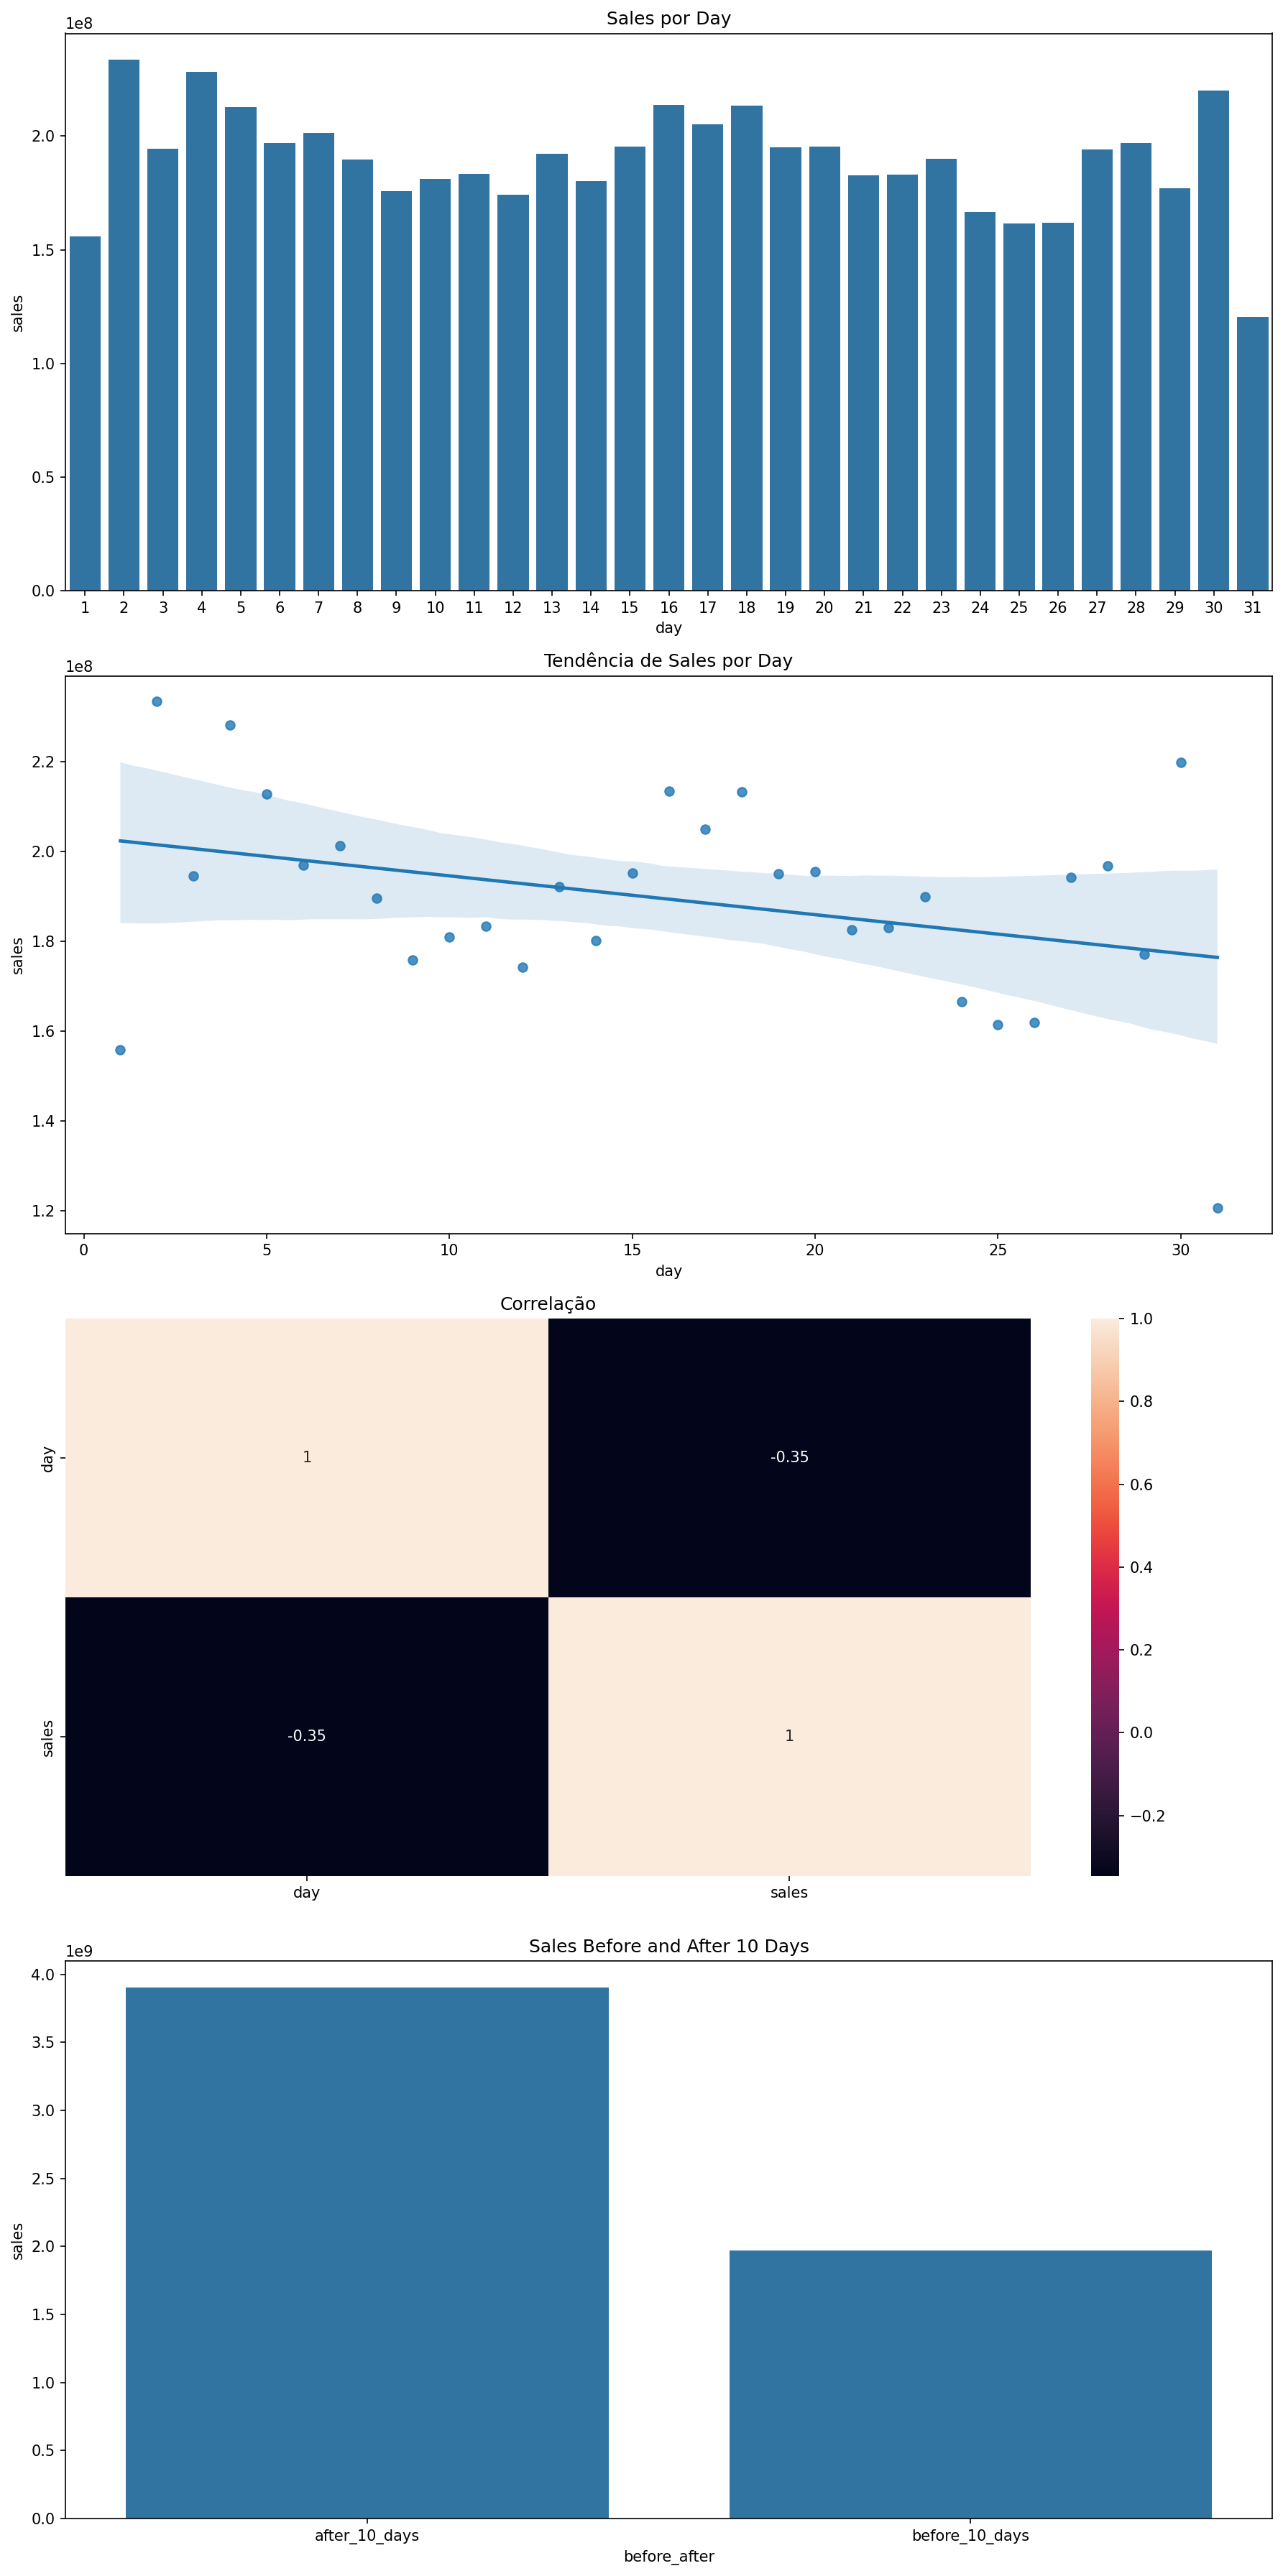

In [40]:
aux1 = df4[['day', 'sales']].groupby('day').sum().reset_index()

aux1['before_after'] = np.where(aux1['day'] <= 10, 'before_10_days', 'after_10_days')
aux2 = aux1[['before_after', 'sales']].groupby('before_after').sum().reset_index()

plt.figure(figsize=(12, 24))

plt.subplot(4, 1, 1)
sns.barplot(x='day', y='sales', data=aux1)
plt.title('Sales por Day')

plt.subplot(4, 1, 2)
sns.regplot(x='day', y='sales', data=aux1)
plt.title('Tendência de Sales por Day')

plt.subplot(4, 1, 3)
sns.heatmap(aux1[['day', 'sales']].corr(method='pearson'), annot=True)
plt.title('Correlação')

plt.subplot(4, 1, 4)
sns.barplot(x='before_after', y='sales', data=aux2)
plt.title('Sales Before and After 10 Days')

plt.tight_layout()
plt.show()

### H11. Lojas deveriam vender menos aos finais de semana.

**VERDADEIRA**

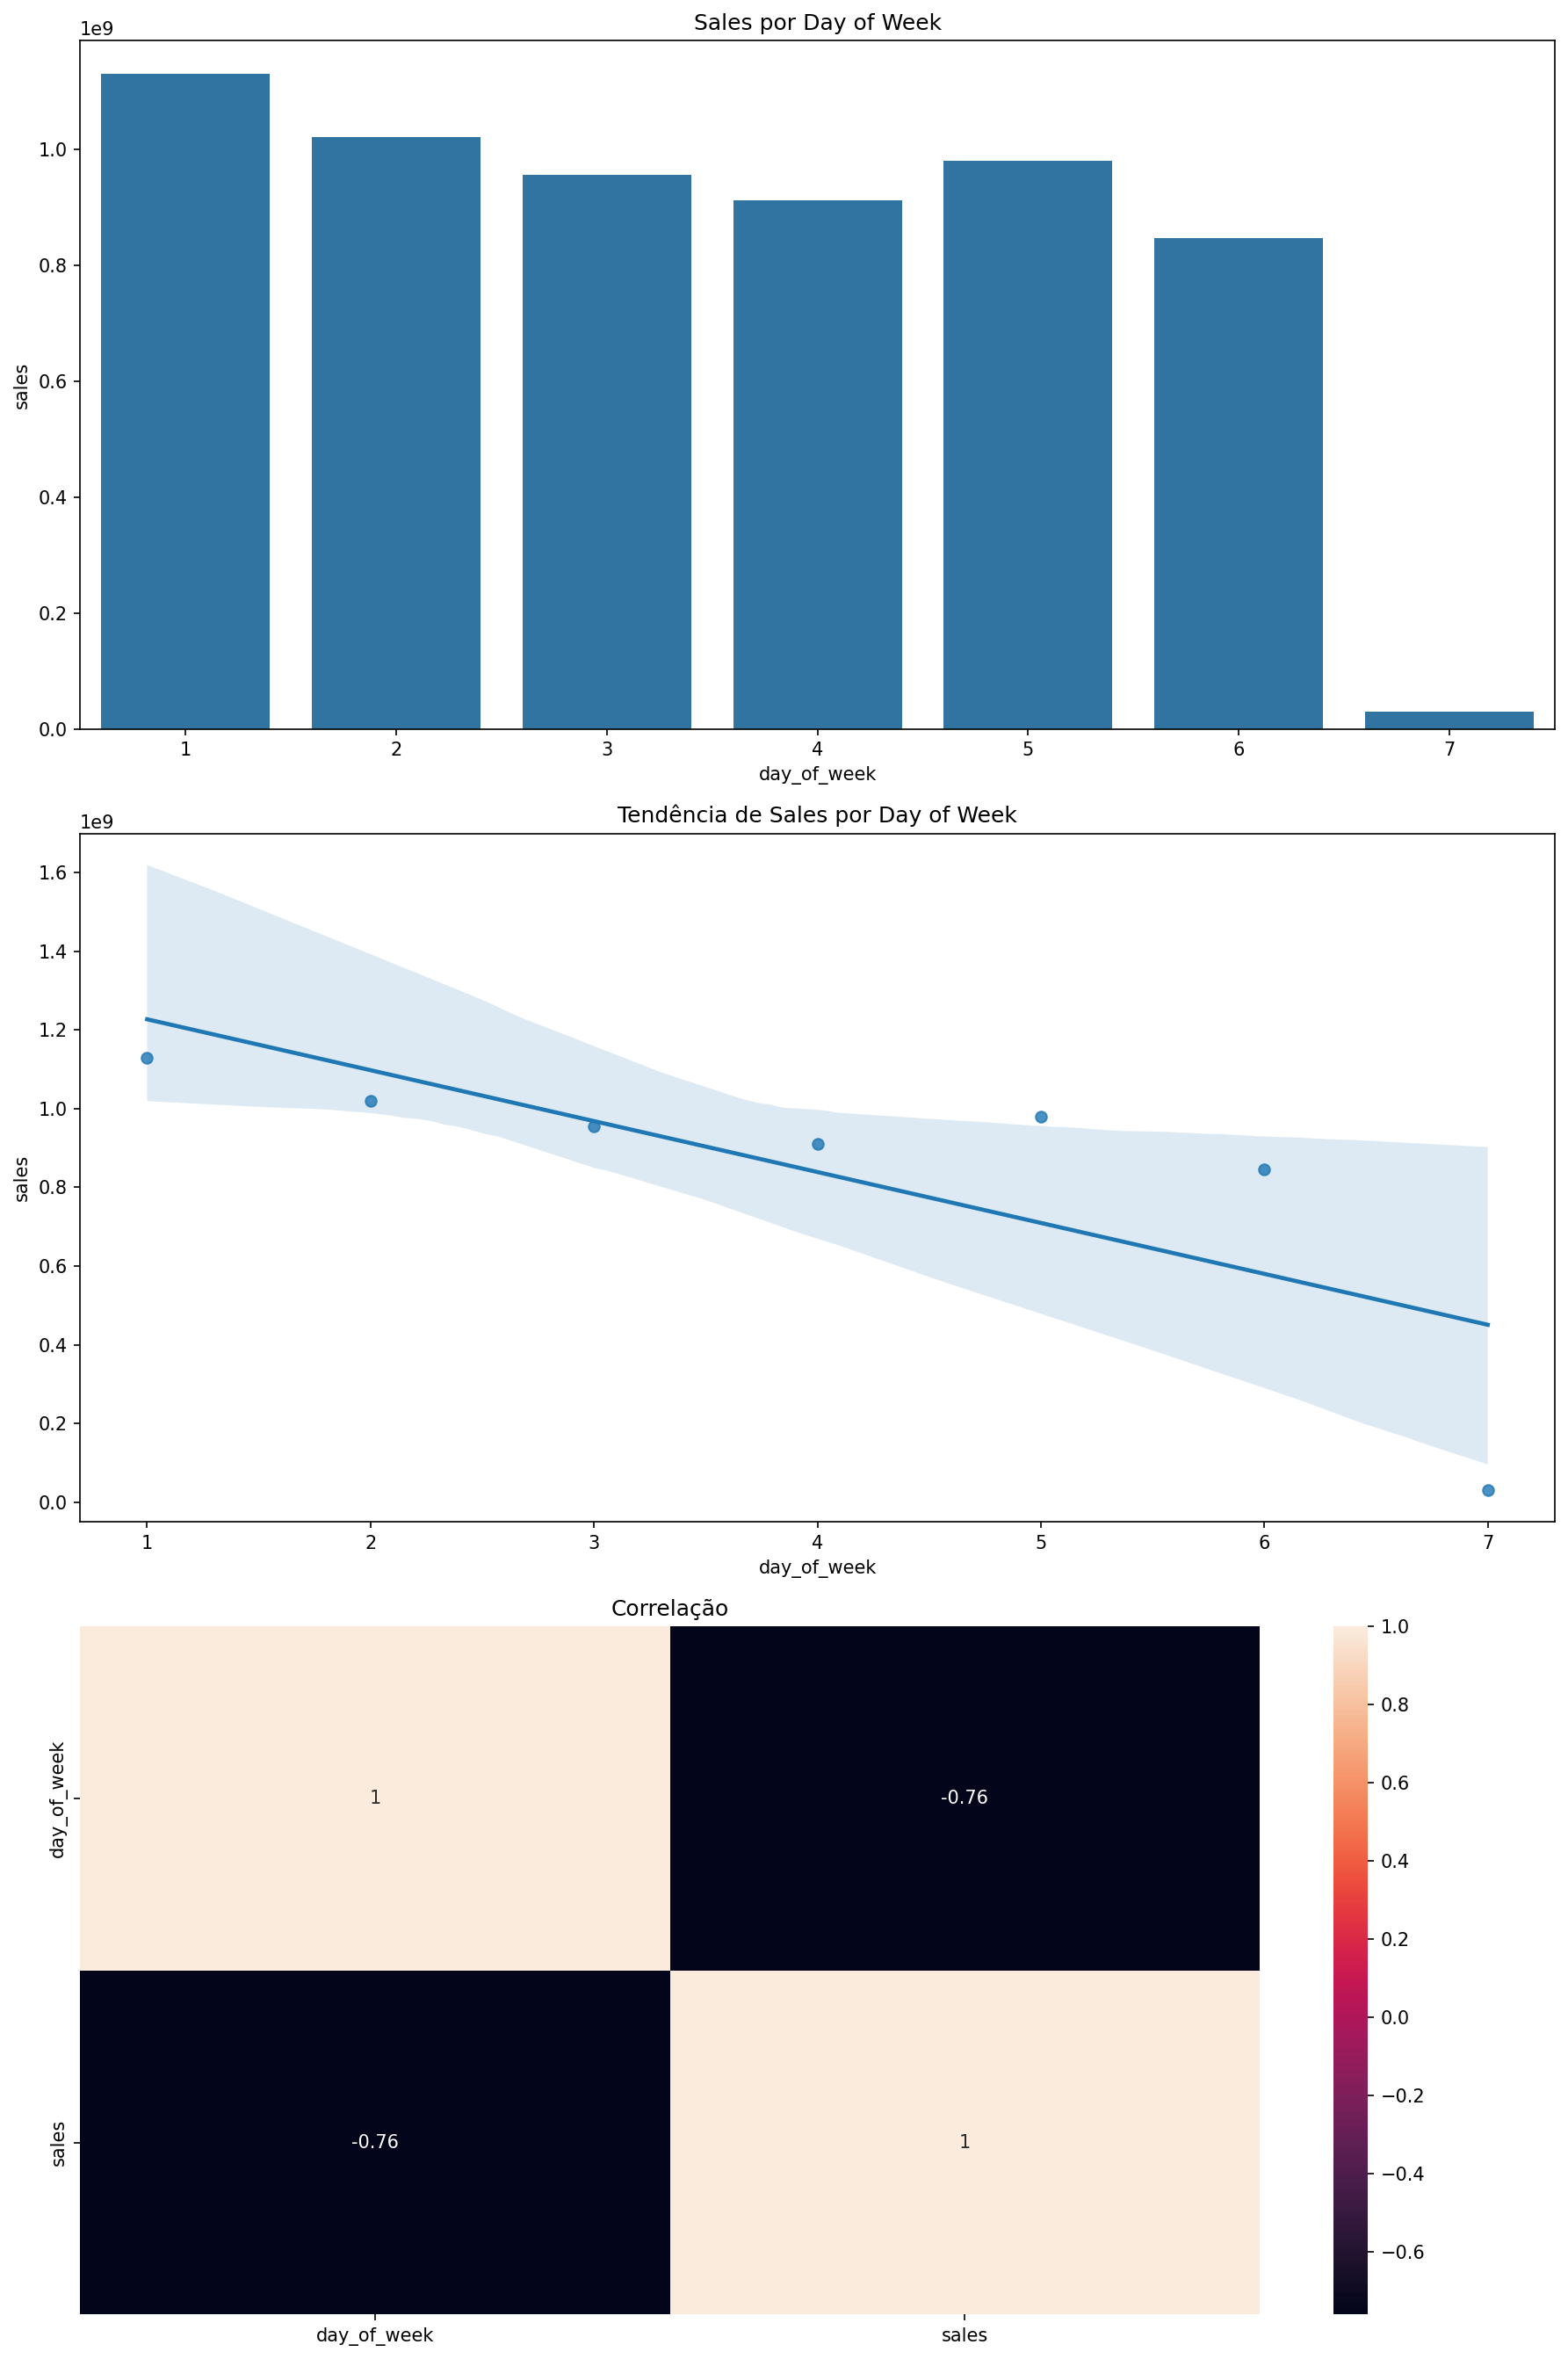

In [41]:
aux1 = df4[['day_of_week', 'sales']].groupby('day_of_week').sum().reset_index()

plt.figure(figsize=(12, 18))

plt.subplot(3, 1, 1)
sns.barplot(x='day_of_week', y='sales', data=aux1)
plt.title('Sales por Day of Week')

plt.subplot(3, 1, 2)
sns.regplot(x='day_of_week', y='sales', data=aux1)
plt.title('Tendência de Sales por Day of Week')

plt.subplot(3, 1, 3)
sns.heatmap(aux1.corr('pearson'), annot=True)
plt.title('Correlação')

plt.tight_layout()
plt.show()

### H12. Lojas deveriam vender menos durante os feriados escolares.
**VERDADEIRA**

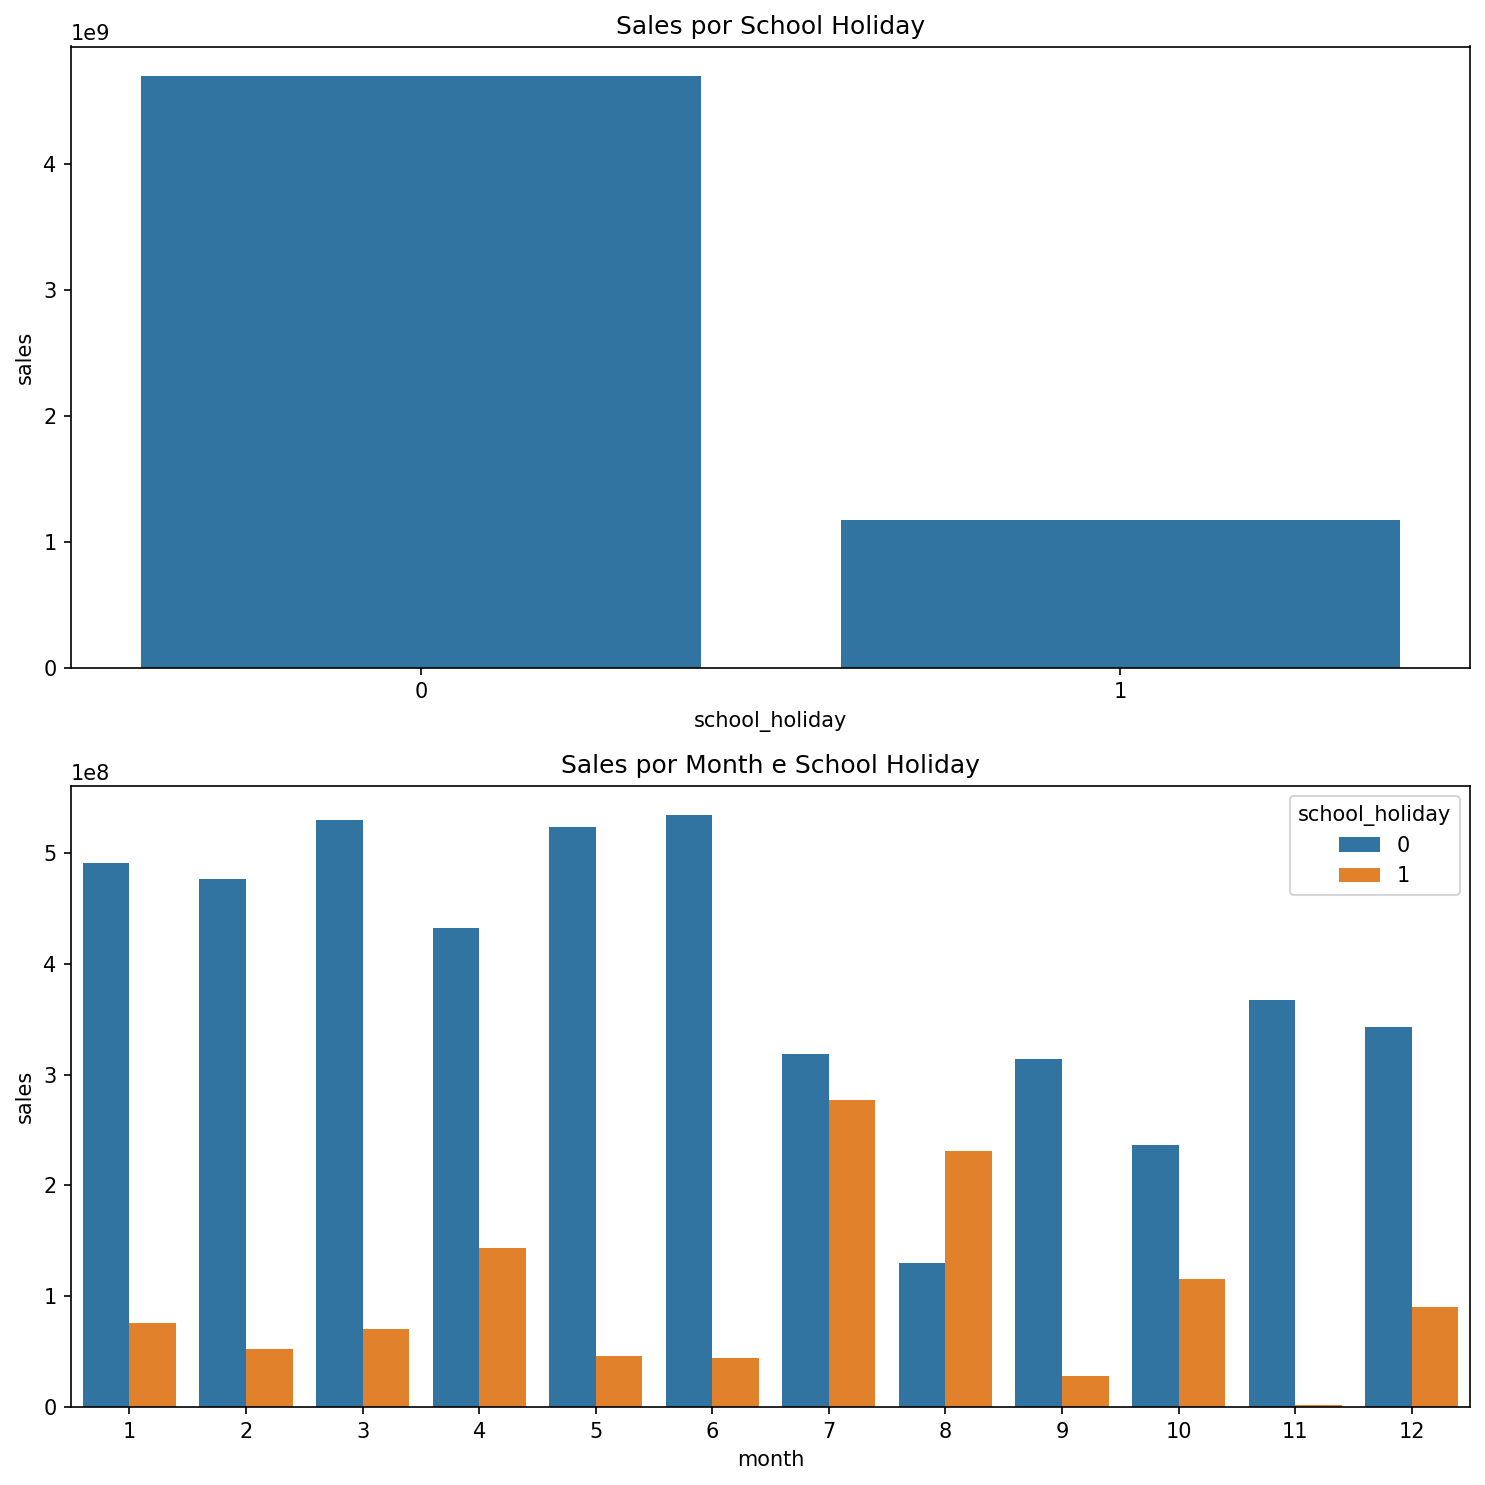

In [42]:
aux1 = df4[['school_holiday', 'sales']].groupby('school_holiday').sum().reset_index()
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
sns.barplot(x='school_holiday', y='sales', data=aux1)
plt.title('Sales por School Holiday')

plt.subplot(2, 1, 2)
aux2 = df4[['month', 'school_holiday', 'sales']].groupby(['month', 'school_holiday']).sum().reset_index()
sns.barplot(x='month', y='sales', hue='school_holiday', data=aux2)
plt.title('Sales por Month e School Holiday')

plt.tight_layout()
plt.show()

## 4.2.1 Resumo das hipóteses

In [43]:
from tabulate import tabulate

tab = [['Hipoteses', 'Conclusao', 'Relevancia'],
       ['H1', 'Falsa', 'Baixa'],
       ['H2', 'Falsa', 'Media'],
       ['H3', 'Falsa', 'Media'],
       ['H4', 'Falsa', 'Baixa'],
       ['H5', '-', '-'],
       ['H7', 'Falsa', 'Baixa'],
       ['H8', 'Falsa', 'Media'],
       ['H9', 'Falsa', 'Alta'],
       ['H10', 'Falsa', 'Alta'],
       ['H11', 'verdadeira', 'Alta'],
       ['H12', 'verdadeira', 'Alta'],
       ['H13', 'verdadeira', 'Baixa'],
      ]

print(tabulate(tab, headers='firstrow'))

Hipoteses    Conclusao    Relevancia
-----------  -----------  ------------
H1           Falsa        Baixa
H2           Falsa        Media
H3           Falsa        Media
H4           Falsa        Baixa
H5           -            -
H7           Falsa        Baixa
H8           Falsa        Media
H9           Falsa        Alta
H10          Falsa        Alta
H11          verdadeira   Alta
H12          verdadeira   Alta
H13          verdadeira   Baixa


## 4.3 Análise multivariada

### 4.3.1 Numerical attributes

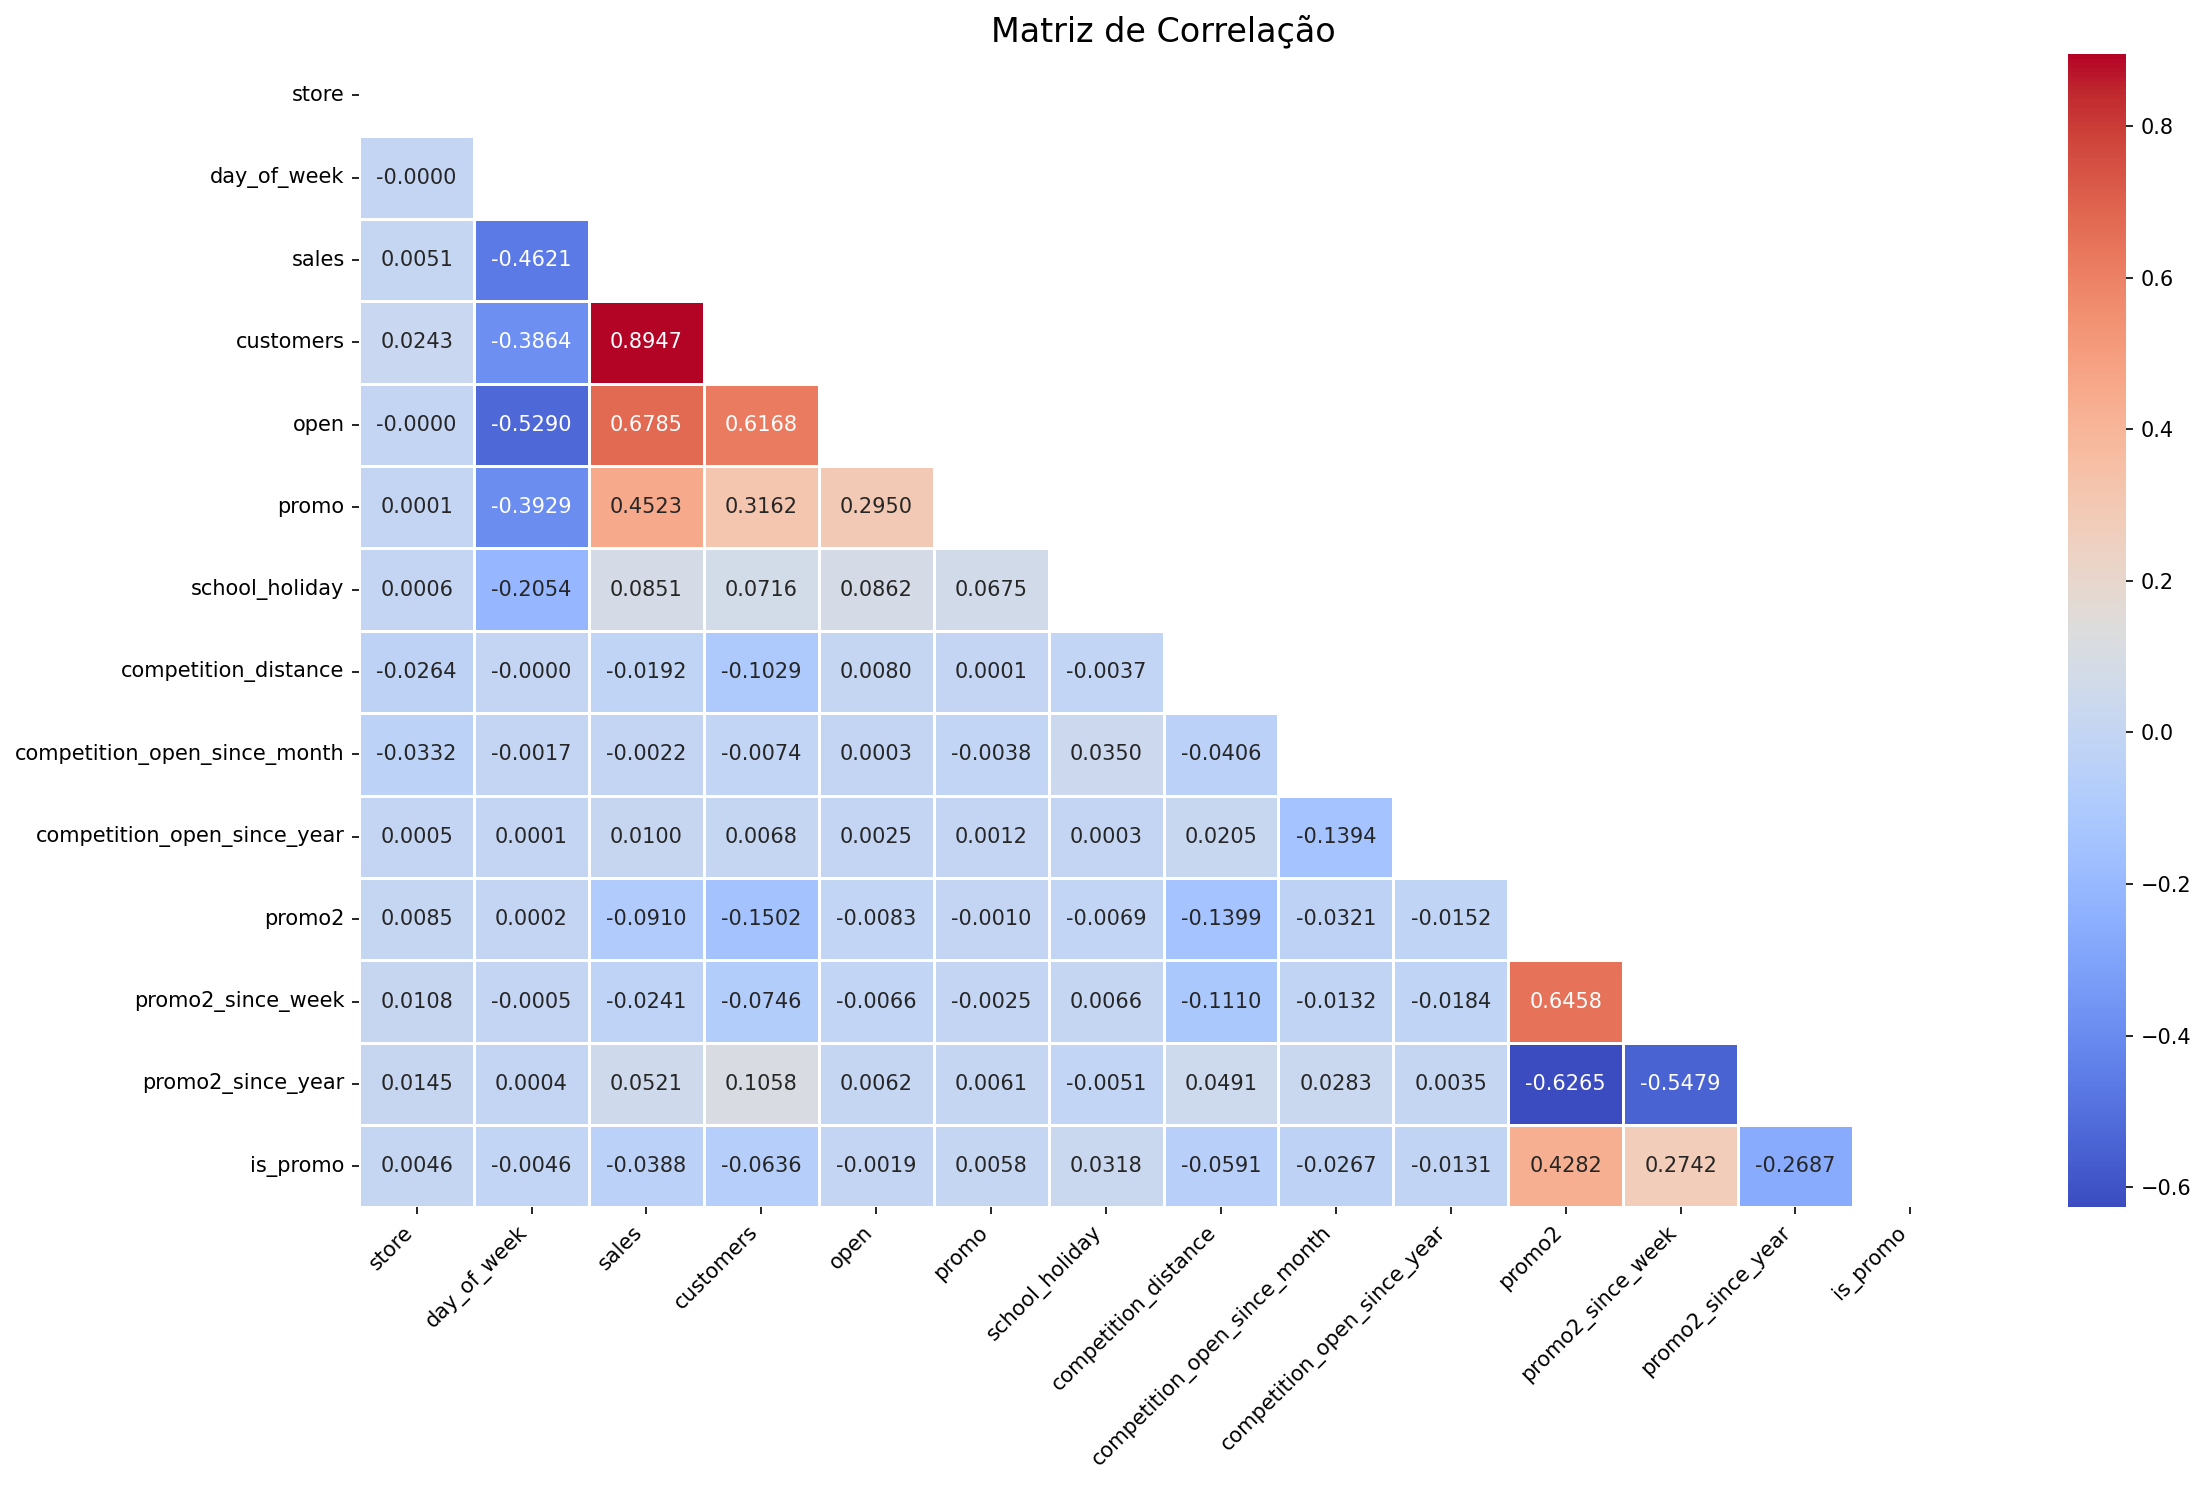

In [44]:
correlation = num_attributes.corr(method='pearson') # usamos o metodo de pearson apenas para variaveis exclusivamente numericas

mask = np.triu(np.ones_like(correlation, dtype=bool))

plt.figure(figsize=(16, 10)) #largura, altura
sns.heatmap(
    correlation,
    mask=mask, #caso tire, o espelhamento do grafico aparece 
    annot=True,
    fmt='.4f',
    cmap='coolwarm', # definicao da paleta de cores
    linewidths=0.5 # espessura das linhas que separam os heatmap
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Matriz de Correlação', fontsize=16)
plt.tight_layout()
plt.show()

### 4.3.2 Categorical attributes

/tmp/ipykernel_1846/3505261262.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  a = df4.select_dtypes( include='object')


<Axes: >

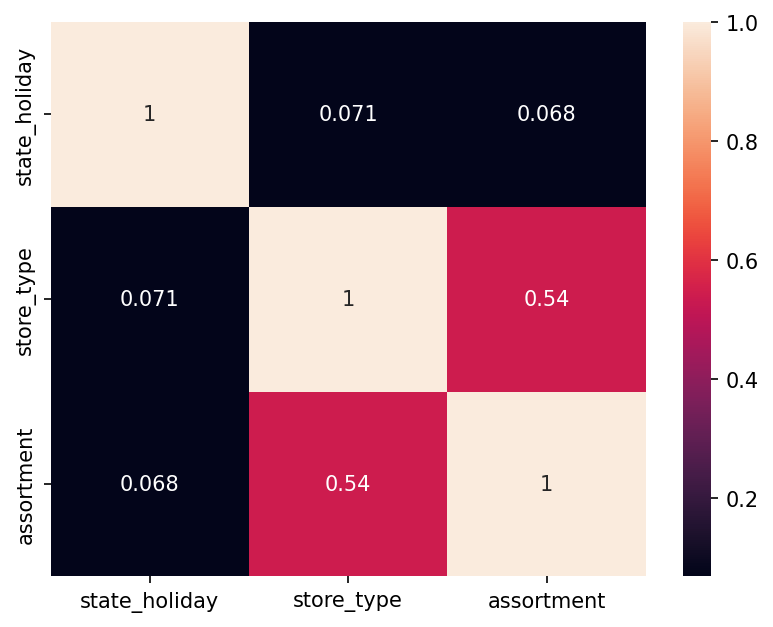

In [45]:
#only categorical df
a = df4.select_dtypes( include='object')

#calculate cramer_v
a1 = cramer_v(a['state_holiday'], a['state_holiday'])
a2 = cramer_v(a['state_holiday'], a['store_type'])
a3 = cramer_v(a['state_holiday'], a['assortment'])

a4 = cramer_v(a['store_type'], a['state_holiday'])
a5 = cramer_v(a['store_type'], a['store_type'])
a6 = cramer_v(a['store_type'], a['assortment'])

a7 = cramer_v(a['assortment'], a['state_holiday'])
a8 = cramer_v(a['assortment'], a['store_type'])
a9 = cramer_v(a['assortment'], a['assortment'])

#Final Dataset
d = pd.DataFrame({'state_holiday' : [a1, a2, a3], 'store_type' : [a4, a5, a6], 'assortment' : [a7, a8, a9]})

d = d.set_index (d.columns)

sns.heatmap(d, annot=True)

# PASSO 5 5.0 PREPARÇÃO DOS DADOS

In [65]:
df5 = df4.copy()

## 5.1. Normalização

## 5.2. Reescaling

In [47]:
rs = RobustScaler()
mms = MinMaxScaler()

#competition distance
df5['competition_distance'] = rs.fit_transform(df5[['competition_distance']].values)

#competition_time_month
df5['competition_time_month'] = rs.fit_transform(df5[['competition_time_month']].values)

#promo_time_week
df5['promo_time_week'] = mms.fit_transform(df5[['promo_time_week']].values)

# year
df5['year'] = mms.fit_transform(df5[['year']].values)

## 5.3. Transformação

### 5.3.1 Encoding

In [ ]:
#state_holiday - One Hot Encoding
df5 = pd.get_dummies(df5, prefix=['state_holiday'], columns=['state_holiday'])
cols = ['state_holiday_christmas', 'state_holiday_easter_holiday','state_holiday_public_holiday','state_holiday_regular_day']
df5[cols] = df5[cols].astype(int)

#store_type - Label encoding
le = LabelEncoder()
df5['store_type'] = le.fit_transform(df5['store_type'])

#assortment - Ordinal Encoding
assortment_dic = {'basic': 1, 'extra' :2, 'extended':3}
df5['assortment'] = df5['assortment'].map(assortment_dic)

In [48]:
# month
# day
#week_of_year
# day of week